## IMPORT DATA, FUNCTIONS AND PREPROCESSING TRIAL'S LENGTH

In [28]:
import os
import mne
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy import stats, interpolate
from mne_connectivity import spectral_connectivity_epochs
import matplotlib.pyplot as plt
import pickle

# === Subject list ===
subject_list = ['wue02', 'wue03', 'wue05', 'wue06', 'wue07', 'wue09', 'wue10', 'wue11']

# === Base path ===
base_path = r'C:\Users\tomma\OneDrive - University of Pisa\Desktop\TESI\Dataset_tesi'

In [29]:
load_path = r'C:\Users\tomma\OneDrive - University of Pisa\Desktop\TESI\Connectivity_Analysis\IMPORT_DATA'

with open(os.path.join(load_path, 'EEG_DATA_ALL.pkl'), 'rb') as f:
    EEG_DATA_ALL = pickle.load(f)

with open(os.path.join(load_path, 'EEG_DATA_ALL_EEG2EEG.pkl'), 'rb') as f:
    EEG_DATA_ALL_EEG2EEG = pickle.load(f)

with open(os.path.join(load_path, 'LFP_DATA_ALL.pkl'), 'rb') as f:
    LFP_DATA_ALL = pickle.load(f)

print("✅ All pickle files loaded successfully.")

✅ All pickle files loaded successfully.


### Control trials' length and tag of valid trials (above samples threshold)

In [ ]:
# Soglia minima di campioni per considerare valido un trial
min_samples_threshold = 154

# Dizionari per salvare validi e invalidi
valid_trials = {}
invalid_trials = {}

for subject_id, blocks in LFP_DATA_ALL.items():

    valid_trials[subject_id] = []
    invalid_trials[subject_id] = []

    for block_idx, block in enumerate(blocks):
        block_valid = []
        block_invalid = []

        for trial_idx, trial in enumerate(block['LFP_phases']):

            # Assumiamo 5 fasi come nel tuo script
            trial_valid = True
            for phase_idx in range(5):
                phase_len = trial[phase_idx].shape[-1]   # lunghezza in campioni

                if phase_len < min_samples_threshold:
                    trial_valid = False
                    break

            if trial_valid:
                block_valid.append(trial_idx)
            else:
                block_invalid.append(trial_idx)

        valid_trials[subject_id].append(block_valid)
        invalid_trials[subject_id].append(block_invalid)
for subject_id in valid_trials:
    print(f"\nSubject: {subject_id}")
    for block_idx in range(len(valid_trials[subject_id])):
        n_total = len(LFP_DATA_ALL[subject_id][block_idx]['LFP_phases'])
        n_valid = len(valid_trials[subject_id][block_idx])
        n_invalid = len(invalid_trials[subject_id][block_idx])
        print(f"  Block {block_idx+1}: {n_valid} valid  |  {n_invalid} invalid  |  total={n_total}")


## MAIN GC CALL FOR SPECTRAL CONNECTIVITY EPOCHS

In [ ]:
# GC for all kinematic phases

GC_PHASE_RESULTS = {}

for subject_id in subject_list:
    print(f"\n=== Computing GC for subject: {subject_id} ===")
    subj_eeg_blocks = EEG_DATA_ALL[subject_id]
    subj_lfp_blocks = LFP_DATA_ALL[subject_id]

    # Canale LFP di interesse
    channel_of_interest = 2 if subject_id in ['wue02', 'wue03'] else 1

    # Raccogliamo tutti i trials validi (length > 120 samples) e le fasi
    all_eeg_phases, all_lfp_phases = [], []
    for block_idx, (EEG_blk, LFP_blk) in enumerate(zip(subj_eeg_blocks, subj_lfp_blocks)):

        block_valid = valid_trials[subject_id][block_idx]

        n_trials_eeg = len(EEG_blk['EEG_phases'])
        n_trials_lfp = len(LFP_blk['LFP_phases'])

        if n_trials_eeg != n_trials_lfp:
            print(f"Skipping block {block_idx+1} due to mismatched trial count")
            continue

        if len(block_valid) == 0:
            print(f"Skipping block {block_idx+1}: no valid trials")
            continue

        print(f"Using {len(block_valid)} valid trials out of {n_trials_eeg} for block {block_idx+1}")

        # Inseriamo SOLO i trial validi
        for tr in block_valid:
            all_eeg_phases.append(EEG_blk['EEG_phases'][tr])
            all_lfp_phases.append(LFP_blk['LFP_phases'][tr])

    n_phases = len(all_eeg_phases[0])
    GC_PHASE_RESULTS[subject_id] = {'LFP2EEG': {}, 'EEG2LFP': {}, 'freqs': None}

    for phase_idx in range(n_phases):
        print(f"\n--- Phase {phase_idx+1} ---")
        # Estrazione trials della fase corrente
        eeg_phase_trials = [trial[phase_idx] for trial in all_eeg_phases]
        lfp_phase_trials = [trial[phase_idx][channel_of_interest-1] for trial in all_lfp_phases]

        # Trimming o padding al minimo tra EEG e LFP
        min_len_eeg = min(trial.shape[1] for trial in eeg_phase_trials)
        min_len_lfp = min(trial.shape[0] if trial.ndim==1 else trial.shape[1] for trial in lfp_phase_trials)
        min_len = min(min_len_eeg, min_len_lfp)

        def trim_phase(phase, min_len):
            phase = phase[np.newaxis, :] if phase.ndim==1 else phase
            return phase[:, :min_len]

        eeg_data = np.stack([trim_phase(t, min_len) for t in eeg_phase_trials])
        lfp_data = np.stack([trim_phase(t, min_len) for t in lfp_phase_trials])

        # Creazione EpochsArray
        sfreq = subj_eeg_blocks[0]['fs']
        eeg_info = mne.create_info(subj_eeg_blocks[0]['chan_names'], sfreq, ch_types='eeg')
        lfp_info = mne.create_info([subj_lfp_blocks[0]['chan_names'][channel_of_interest-1]], sfreq, ch_types='seeg')

        epochs_eeg = mne.EpochsArray(eeg_data, eeg_info)
        epochs_lfp = mne.EpochsArray(lfp_data, lfp_info)

        epochs_combined = mne.EpochsArray(
            np.concatenate([lfp_data, eeg_data], axis=1),
            mne.create_info([lfp_info.ch_names[0]] + eeg_info.ch_names,
                            sfreq,
                            ch_types=['seeg'] + ['eeg']*len(eeg_info.ch_names))
        )

        # Indici seed-target
        indices_LFP2EEG = (
        [np.array([0])] * len(epochs_eeg.ch_names),     
        [np.array([i]) for i in range(1, len(epochs_combined.ch_names))]
        )
        indices_EEG2LFP = (
            [np.array([i]) for i in range(1, len(epochs_combined.ch_names))],
            [np.array([0])] * len(epochs_eeg.ch_names)
        )
    
        GC_lags = 40; 

        T_epoch = min_len / sfreq

        # determine fmin to avoid warning (5 cycles rule)
        fmin = max(1.0, 5 / T_epoch) 

        # --- GC 1-100 Hz ---
        gc_L2E = spectral_connectivity_epochs(
            epochs_combined, names=epochs_combined.ch_names, indices=indices_LFP2EEG,
            mode='multitaper', method='gc', fmin=fmin, fmax=100, gc_n_lags = GC_lags,
            faverage=False, mt_adaptive=True, mt_low_bias=True, sfreq=sfreq
        )

        gc_E2L = spectral_connectivity_epochs(
            epochs_combined, names=epochs_combined.ch_names, indices=indices_EEG2LFP,
            mode='multitaper', method='gc', fmin=fmin, fmax=100, gc_n_lags = GC_lags,
            faverage=False, mt_adaptive=True, mt_low_bias=True, sfreq=sfreq
        )
        
        gc_tr_L2E = spectral_connectivity_epochs(
            epochs_combined, names=epochs_combined.ch_names, indices=indices_LFP2EEG,
            mode='multitaper', method='gc_tr', fmin=fmin, fmax=100, gc_n_lags = GC_lags,
            faverage=False, mt_adaptive=True, mt_low_bias=True, sfreq=sfreq
        )

        gc_tr_E2L = spectral_connectivity_epochs(
            epochs_combined, names=epochs_combined.ch_names, indices=indices_EEG2LFP,
            mode='multitaper', method='gc_tr', fmin=fmin, fmax=100, gc_n_lags = GC_lags,
            faverage=False, mt_adaptive=True, mt_low_bias=True, sfreq=sfreq
        )

        # Salvataggio valori GC_TR nel dizionario
        GC_PHASE_RESULTS[subject_id]['LFP2EEG'][f'phase_{phase_idx+1}'] = {
            'gc': gc_L2E.get_data().squeeze() - gc_tr_L2E.get_data().squeeze(),
            'freqs': gc_L2E.freqs
        }

        GC_PHASE_RESULTS[subject_id]['EEG2LFP'][f'phase_{phase_idx+1}'] = {
            'gc': gc_E2L.get_data().squeeze() - gc_tr_E2L.get_data().squeeze() ,
            'freqs': gc_E2L.freqs
        }
        


print("\n✅ GC computed for all subjects and phases!")

print("\n💾 Saving results to pickle...")
output_filename = 'GC_PHASE_RESULTS_default_fmin.pkl'

try:
    with open(output_filename, 'wb') as f:
        pickle.dump(GC_PHASE_RESULTS, f)
    print(f"File saved successfully as: **{output_filename}**")

except Exception as e:
    print(f"❌ Error during pickle save: {e}")


### IMPORT FROM PICKLE TO AVOID RERUNNING MAIN CELL

In [45]:
# File pickle precedentemente salvato
input_filename = 'GC_PHASE_RESULTS_default_fmin.pkl'

try:
    with open(input_filename, 'rb') as f:
        GC_PHASE_RESULTS = pickle.load(f)
    print(f"✅ GC_PHASE_RESULTS loaded successfully from {input_filename}")

except Exception as e:
    print(f"❌ Error loading pickle: {e}")

✅ GC_PHASE_RESULTS loaded successfully from GC_PHASE_RESULTS_default_fmin.pkl


## COMPUTATION NET GC FROM EEG->LFP AND LFP->EEG SCORES

In [46]:
GC_NET_RESULTS = {}
bands = {
    'beta_low': (13, 20),
    'beta_high': (20, 30),
    'gamma': (30, 80)
}

for subject_id in GC_PHASE_RESULTS.keys():
    print(f"→ Computing GC Net for {subject_id}...")

    GC_NET_RESULTS[subject_id] = {'phases': {}}

    # Scorriamo le fasi
    for phase_key in GC_PHASE_RESULTS[subject_id]['LFP2EEG'].keys():

        # Estraggo GC e frequenze della fase attuale
        gc_L2E = np.array(GC_PHASE_RESULTS[subject_id]['LFP2EEG'][phase_key]['gc'])
        freqs = np.array(GC_PHASE_RESULTS[subject_id]['LFP2EEG'][phase_key]['freqs'], dtype=float)

        gc_E2L = np.array(GC_PHASE_RESULTS[subject_id]['EEG2LFP'][phase_key]['gc'])

        # Calcolo GC Net
        gc_net = gc_E2L - gc_L2E

        # Salvataggio base
        GC_NET_RESULTS[subject_id]['phases'][phase_key] = {
            'freqs': freqs,
            'full': gc_net
        }

        # --- Bande ---
        for band_name, (fmin, fmax) in bands.items():

            # Indici di banda (sulla base delle frequenze della fase)
            idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]

            # Sicurezza: niente out-of-bounds
            idx = idx[idx < gc_net.shape[1]]

            if len(idx) == 0:
                print(f"⚠️ Nessuna freq in banda {band_name} per {subject_id} ({phase_key}).")
                GC_NET_RESULTS[subject_id]['phases'][phase_key][band_name] = np.full(gc_net.shape[0], np.nan)
                continue

            # Media GC Net sulla banda
            GC_NET_RESULTS[subject_id]['phases'][phase_key][band_name] = np.mean(gc_net[:, idx], axis=1)


→ Computing GC Net for wue02...
→ Computing GC Net for wue03...
→ Computing GC Net for wue05...
→ Computing GC Net for wue06...
→ Computing GC Net for wue07...
→ Computing GC Net for wue09...
→ Computing GC Net for wue10...
→ Computing GC Net for wue11...


### MIRRORING OF GC NET SCORES FOR LEFT HANDES SUBJECTS

In [ ]:
import re

def mirror_gc_net(subject_id, data_dict, chan_names, full_freq=False):
    """
    Esegue lo swap L/R dei canali per un soggetto nella struttura GC_NET_RESULTS.
    full_freq=False -> struttura a bande
    full_freq=True  -> struttura full frequency
    """
    for phase_key, phase_data in data_dict[subject_id]['phases'].items():
        print(f"\n[{('Full freq' if full_freq else 'Bande')}] Phase: {phase_key}")
        swapped_channels = []
        global_swaps = set()

        if full_freq:
            gc_net = phase_data['full'].copy()
            swapped_indices = set()
            for ch_idx, label in enumerate(chan_names):
                if ch_idx in swapped_indices:
                    continue
                m = re.search(r'(\d+)([A-Za-z]*)$', label)
                if not m:
                    continue
                num, suffix = int(m.group(1)), m.group(2)
                tgt_num = num + 1 if num % 2 else num - 1
                tgt_label = re.sub(r'\d+[A-Za-z]*$', f"{tgt_num}{suffix}", label)
                if tgt_label not in chan_names:
                    continue
                tgt_idx = chan_names.index(tgt_label)
                pair = tuple(sorted([ch_idx, tgt_idx]))
                if pair in global_swaps:
                    continue

                # Swap righe
                gc_net[[ch_idx, tgt_idx], :] = gc_net[[tgt_idx, ch_idx], :].copy()
                swapped_channels.append((label, tgt_label))
                global_swaps.add(pair)
                swapped_indices.update(pair)

            data_dict[subject_id]['phases'][phase_key]['full'] = gc_net

        else:
            for band_name, band_data in phase_data.items():
                if band_name == 'freqs':
                    continue
                global_swaps = set()
                gc_band = np.array(band_data).copy()
                swapped_indices = set()
                for ch_idx, label in enumerate(chan_names):
                    if ch_idx in swapped_indices:
                        continue
                    m = re.search(r'(\d+)([A-Za-z]*)$', label)
                    if not m:
                        continue
                    num, suffix = int(m.group(1)), m.group(2)
                    tgt_num = num + 1 if num % 2 else num - 1
                    tgt_label = re.sub(r'\d+[A-Za-z]*$', f"{tgt_num}{suffix}", label)
                    if tgt_label not in chan_names:
                        continue
                    tgt_idx = chan_names.index(tgt_label)
                    pair = tuple(sorted([ch_idx, tgt_idx]))
                    if pair in global_swaps:
                        continue

                    # Swap valori
                    gc_band[ch_idx], gc_band[tgt_idx] = gc_band[tgt_idx], gc_band[ch_idx]
                    swapped_channels.append((label, tgt_label))
                    global_swaps.add(pair)
                    swapped_indices.update(pair)

                data_dict[subject_id]['phases'][phase_key][band_name] = gc_band

        if swapped_channels:
            print(f"[SUMMARY] Subject={subject_id} | Phase={phase_key} | {'Full freq' if full_freq else 'Bande'}")
            print(f"  → Swapped channels: {swapped_channels}")


# === MAIN ===
left_handed_subjects = [subject_list[2], subject_list[5]]

for sid in left_handed_subjects:
    print(f"\n=== Mirroring GC Net results for left-handed subject: {sid} ===")
    chans = EEG_DATA_ALL[sid][0]['chan_names']
    print(f"→ Canali totali: {len(chans)} | Esempi: {chans[:10]}")

    mirror_gc_net(sid, GC_NET_RESULTS, chans, full_freq=False)
    mirror_gc_net(sid, GC_NET_RESULTS, chans, full_freq=True)

    print(f"✅ Done for subject: {sid}")

print("\n✅ Full mirroring completed for left-handed subjects.")


### PICKLE DUMP

In [12]:
output_filename = 'GC_NET_RESULTS_default_final.pkl'

try:
    with open(output_filename, 'wb') as f:
        pickle.dump(GC_NET_RESULTS, f)
    print(f"File saved successfully as: **{output_filename}**")

except Exception as e:
    print(f"❌ Error during pickle save: {e}")

File saved successfully as: **GC_NET_RESULTS_default_final.pkl**


## TOPOPLOT ANALYSIS

### SINGLE SUBJECT TOPOPLOT GC NET

In [ ]:
phase_name_map = {
    'phase_1': 'Rest Pre',
    'phase_2': 'Reach',
    'phase_3': 'Grasp',
    'phase_4': 'Pull',
    'phase_5': 'Rest Post'
}

mean_gcnet_data = {band: {} for band in bands.keys()}

for subject_id in GC_NET_RESULTS.keys():
    print(f"→ Plotting GC Net topomaps for {subject_id}...")
    
    # Montaggio EEG
    montage_eeg = EEG_DATA_ALL[subject_id][0]['montage']
    eeg_info = mne.create_info(
        ch_names=EEG_DATA_ALL[subject_id][0]['chan_names'],
        sfreq=EEG_DATA_ALL[subject_id][0]['fs'],
        ch_types='eeg'
    )
    epochs_eeg = mne.EpochsArray(
        np.zeros((1, len(eeg_info['ch_names']), 100)),
        eeg_info
    )
    epochs_eeg.set_montage(montage_eeg)

    phase_keys = GC_NET_RESULTS[subject_id]['phases'].keys()

    for band_name in bands.keys():
        fig, axes = plt.subplots(1, len(phase_keys), figsize=(3*len(phase_keys), 5))
        if len(phase_keys) == 1:
            axes = [axes]
        
        for i, phase_key in enumerate(phase_keys):
            gc_vals = GC_NET_RESULTS[subject_id]['phases'][phase_key][band_name]

            # accumulate for mean across subjects
            if phase_key not in mean_gcnet_data[band_name]:
                mean_gcnet_data[band_name][phase_key] = []
            mean_gcnet_data[band_name][phase_key].append(gc_vals)

            im, _ = mne.viz.plot_topomap(
                gc_vals,
                epochs_eeg.info,
                axes=axes[i],
                show=False,
                contours=0,
                cmap='RdBu_r',
                size=1.3,
                outlines='head',
                names=epochs_eeg.ch_names
            )

            phase_label = phase_name_map.get(phase_key, phase_key)
            axes[i].set_title(phase_label, fontsize=12)

        # Colorbar
        cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
        cbar.set_label('GC Net (EEG→LFP − LFP→EEG)', fontsize=12)

        fig.suptitle(f"{subject_id} - {band_name.replace('_',' ').title()} - GC Net", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


### GRAND AVERAGE TOPOPLOT GC NET


→ Plotting MEAN GC Net across subjects with uniform colorbar...
Max absolute value across all bands and phases: 0.06594


C:\Users\tomma\AppData\Local\Temp\ipykernel_6392\3383963168.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.01,1,0.95])


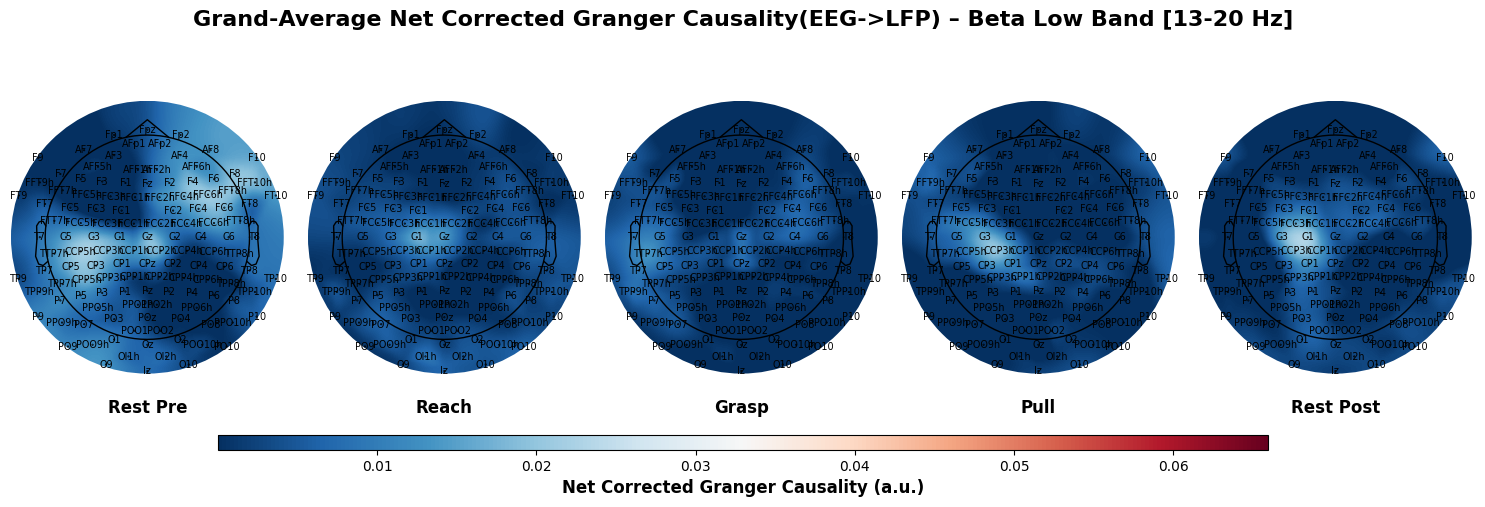

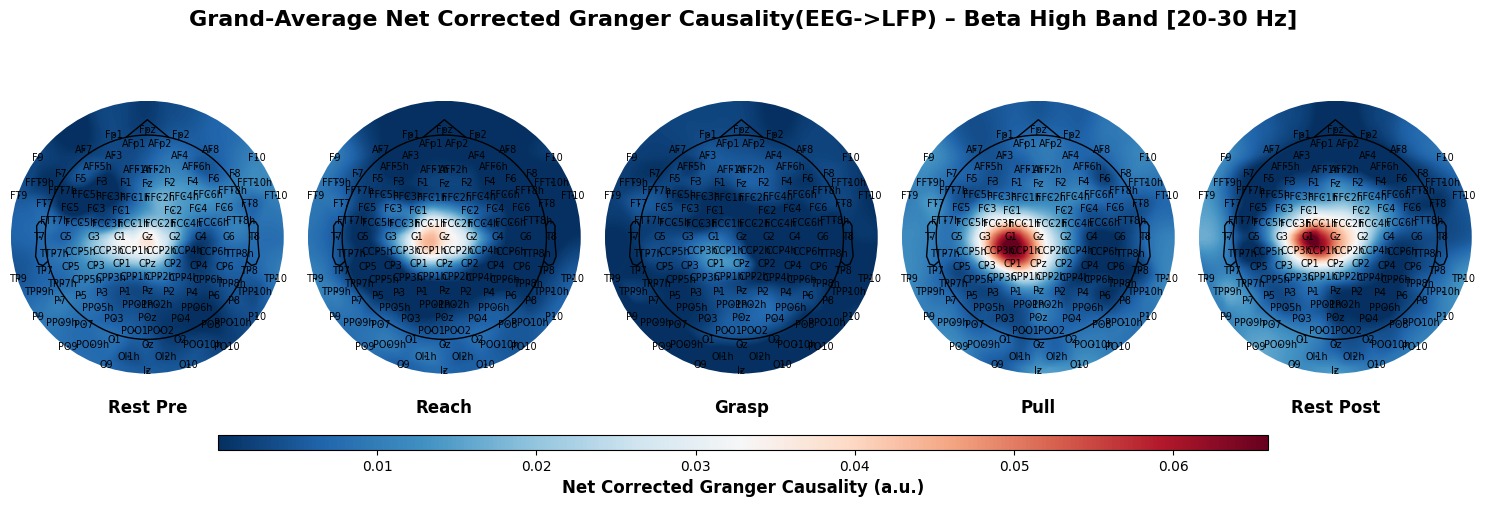

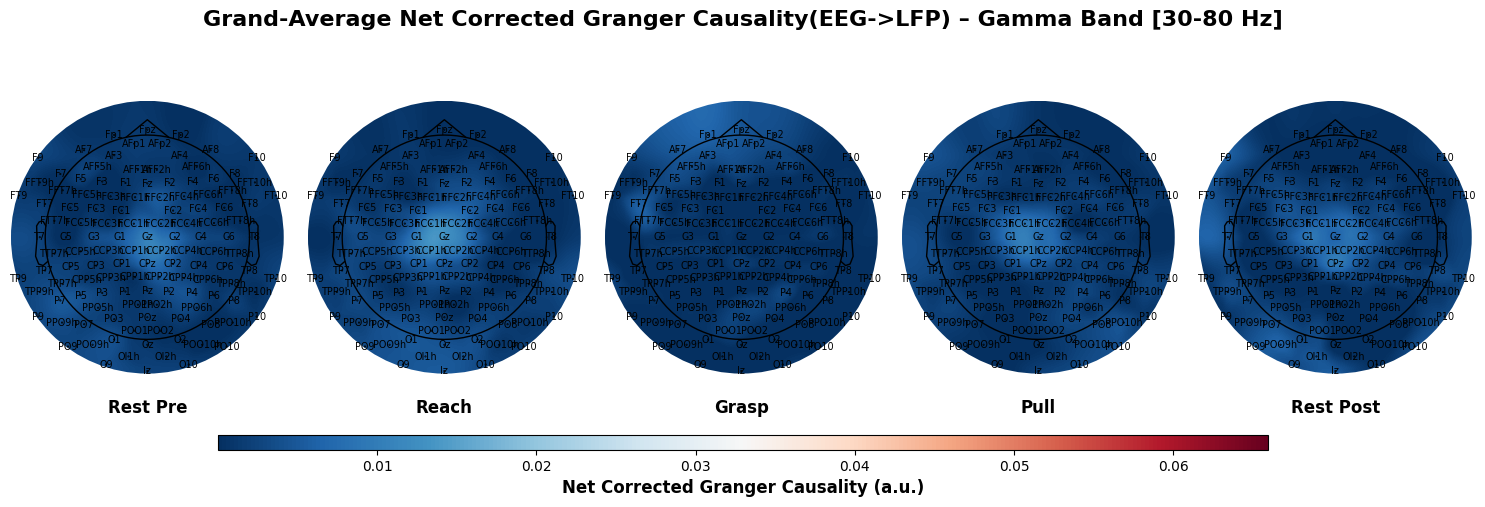

In [49]:
# Topoplot MEDIO TRA SOGGETTI IN ALL BANDS 

Freq_Bands = {
    'beta_low': (13, 20),
    'beta_high': (20, 30),
    'gamma': (30, 80)
}


print("\n→ Plotting MEAN GC Net across subjects with uniform colorbar...")

# ===========================
# 1. Troviamo il massimo assoluto globale tra tutte le bande e fasi
# ===========================
all_vals_global = []

for band_name in bands.keys():
    phase_keys = list(mean_gcnet_data[band_name].keys())
    for phase_key in phase_keys:
        all_vals = np.vstack(mean_gcnet_data[band_name][phase_key])
        mean_vals = np.mean(all_vals, axis=0)
        all_vals_global.append(mean_vals)

max_abs = np.max(np.abs(np.concatenate(all_vals_global)))
min_abs = np.min(np.abs(np.concatenate(all_vals_global)))
print(f"Max absolute value across all bands and phases: {max_abs:.5f}")

# ===========================
# 2. Plot per banda con colorbar uniforme
# ===========================
for band_name in bands.keys():
    phase_keys = list(mean_gcnet_data[band_name].keys())

    fig, axes = plt.subplots(1, len(phase_keys), figsize=(3*len(phase_keys), 5))
    if len(phase_keys) == 1:
        axes = [axes]

    for i, phase_key in enumerate(phase_keys):
        all_vals = np.vstack(mean_gcnet_data[band_name][phase_key])
        mean_vals = np.mean(all_vals, axis=0)

        im, _ = mne.viz.plot_topomap(
            mean_vals,
            epochs_eeg.info,
            axes=axes[i],
            show=False,
            contours=0,
            cmap='RdBu_r',
            size=1.3,
            outlines='head',
            names=epochs_eeg.ch_names
        )

        # Forziamo la stessa scala globale
        im.set_clim(min_abs, max_abs)

        # Nome fase in basso rispetto al topoplot
        axes[i].text(0, -0.15, f"{phase_name_map.get(phase_key, phase_key)}",
                     fontsize=12, fontweight='bold',
                     horizontalalignment='center', verticalalignment='top')

    # Barra colore unica più in basso
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.03]) 
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Net Corrected Granger Causality (a.u.)', fontsize=12, fontweight='bold')

    # Limiti banda
    band_lower, band_upper = Freq_Bands[band_name.lower()]

    # Titolo principale in alto
    fig.suptitle(
        f"Grand-Average Net Corrected Granger Causality(EEG->LFP) – {band_name.replace('_',' ').title()} Band [{band_lower}-{band_upper} Hz]",
        fontsize=16,
        fontweight='bold',
        y=0.90
    )
    plt.tight_layout(rect=[0,0.01,1,0.95])  
    plt.show()
    


## EXTRACTION OF GC ROI IN HIGH BETA BAND


=== Extracting ROI for beta_high using phases phase_1 and phase_5 ===
Soglia (percentile 95): 0.02698

=== ROI Channels (High Beta, REST_PRE+POST) ===
Number of selected channels: 7
Channels: ['C1', 'CCP1h', 'CCP2h', 'CCP3h', 'Cz', 'FCC1h', 'FCC2h']


C:\Users\tomma\AppData\Local\Temp\ipykernel_6392\2178043373.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


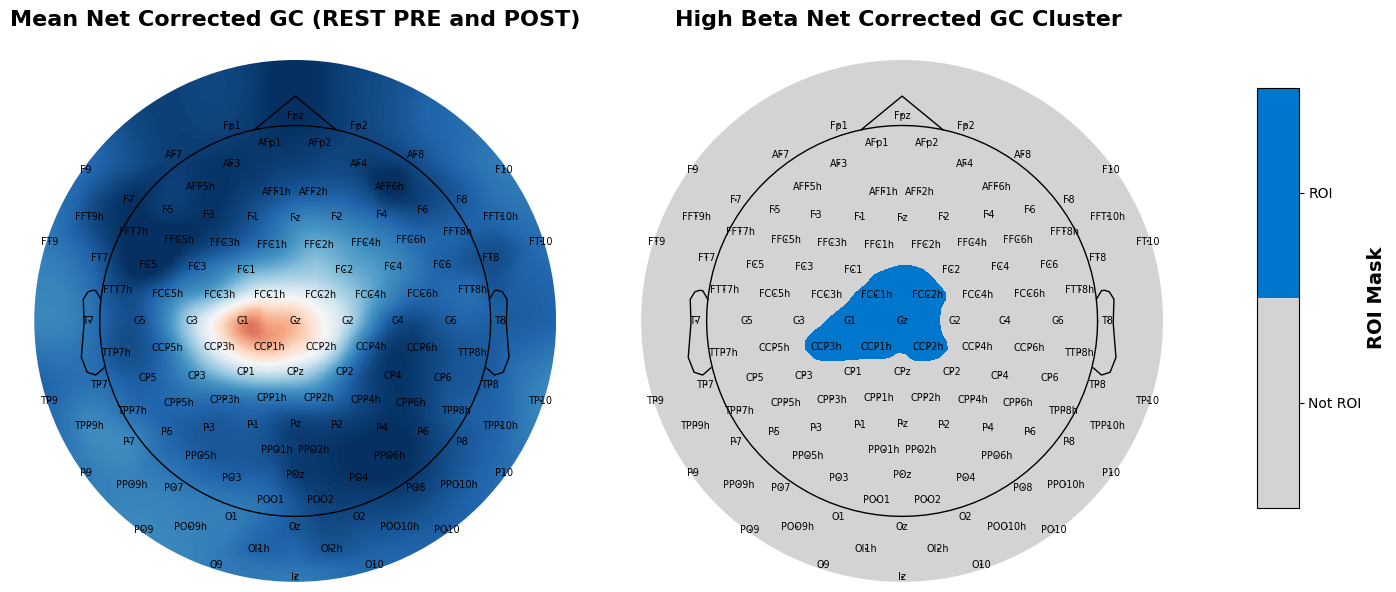

In [50]:
# ============================
#   HIGH-BETA ROI EXTRACTION
#   --> REGIONE NEL REST MEDIO in cui si localizza net GC alle high beta
# ============================

import matplotlib as mpl

band_name = 'beta_high'
phase_pre = 'phase_1'
phase_post = 'phase_5'
percentile_thr = 95  # soglia percentile 90°

print(f"\n=== Extracting ROI for {band_name} using phases {phase_pre} and {phase_post} ===")

# 1. Estrai valori di tutti i soggetti per le due fasi
vals_pre = np.vstack(mean_gcnet_data[band_name][phase_pre])   # shape: (n_subj, n_channels)
vals_post = np.vstack(mean_gcnet_data[band_name][phase_post]) # shape: (n_subj, n_channels)

# 2. Media sui soggetti
mean_pre = np.mean(vals_pre, axis=0)   # shape: (n_channels,)
mean_post = np.mean(vals_post, axis=0)

# 3. Media tra REST_PRE e REST_POST per canale
mean_rest = (mean_pre + mean_post) / 2.0

# 4. Calcolo soglia percentile sull'assoluto
thr_value = np.percentile(np.abs(mean_rest), percentile_thr)

print(f"Soglia (percentile {percentile_thr}): {thr_value:.5f}")

# 5. Selezione canali sopra soglia
roi_indices = np.where(np.abs(mean_rest) >= thr_value)[0]
roi_names = [epochs_eeg.ch_names[i] for i in roi_indices]

# 6. Stampa finale
print("\n=== ROI Channels (High Beta, REST_PRE+POST) ===")
print(f"Number of selected channels: {len(roi_indices)}")
print("Channels:", roi_names)

# 8. Salviamo anche i nomi nel cluster significativo globale
SIGNIFICANT_CLUSTER_CHANNELS = roi_names

# -------------------------
#        FIGURA DOPPIA TOPOMAP
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1️⃣ Topoplot medio REST_PRE+POST
im1, _ = mne.viz.plot_topomap(
    mean_rest,
    epochs_eeg.info,
    axes=axes[0],
    show=False,
    contours=0,
    sensors=True,
    names=epochs_eeg.ch_names,
    cmap='RdBu_r',
)
axes[0].set_title(
    "Mean Net Corrected GC (REST PRE and POST)",
    fontsize=16,
    fontweight='bold',
    y=1.05
)
im1.set_clim(min_abs, max_abs)

# 2️⃣ Topoplot binario cluster ROI
binary_mask = np.zeros(len(mean_rest))
binary_mask[roi_indices] = 1

cmap = mpl.colors.ListedColormap(['lightgray', '#0077CC'])
norm = mpl.colors.Normalize(vmin=0, vmax=1)

im2, _ = mne.viz.plot_topomap(
    binary_mask,
    epochs_eeg.info,
    axes=axes[1],
    show=False,
    contours=0,
    sensors=True,
    names=epochs_eeg.ch_names,
    cmap=cmap,
    cnorm=norm
)
axes[1].set_title(
    f"High Beta Net Corrected GC Cluster ",
    fontsize=16,
    fontweight='bold',
    y=1.05
)

# Colorbar verticale a destra del secondo topoplot
cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, ticks=[0.25, 0.75])
cbar.set_ticklabels(['Not ROI', 'ROI'])
cbar.set_label("ROI Mask", fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()



## GC NET SPECTRUM ANALYSIS

### SINGLE SUBJECT GC NET SPECTRUM IN GC ROI


Plotting GC for subject: wue02


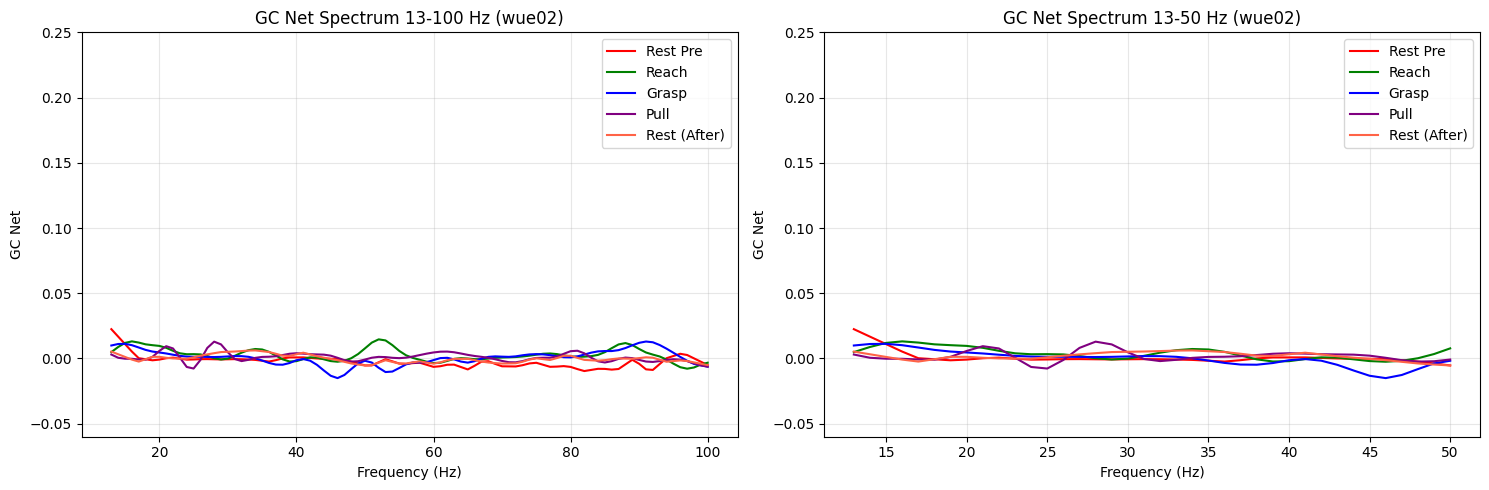


Plotting GC for subject: wue03


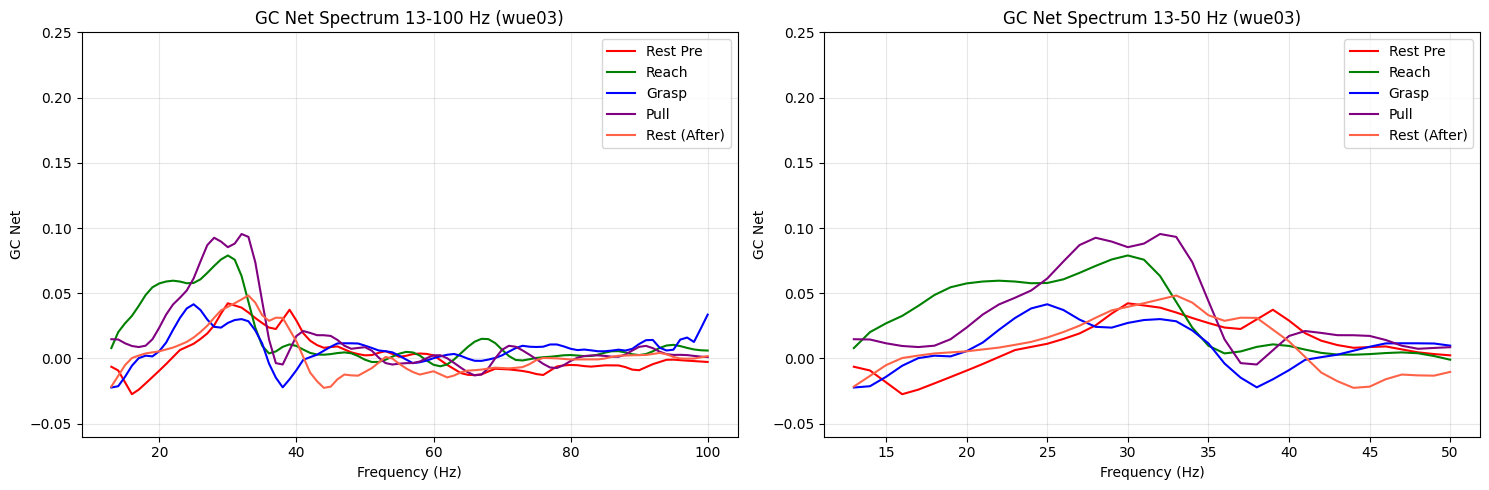


Plotting GC for subject: wue05


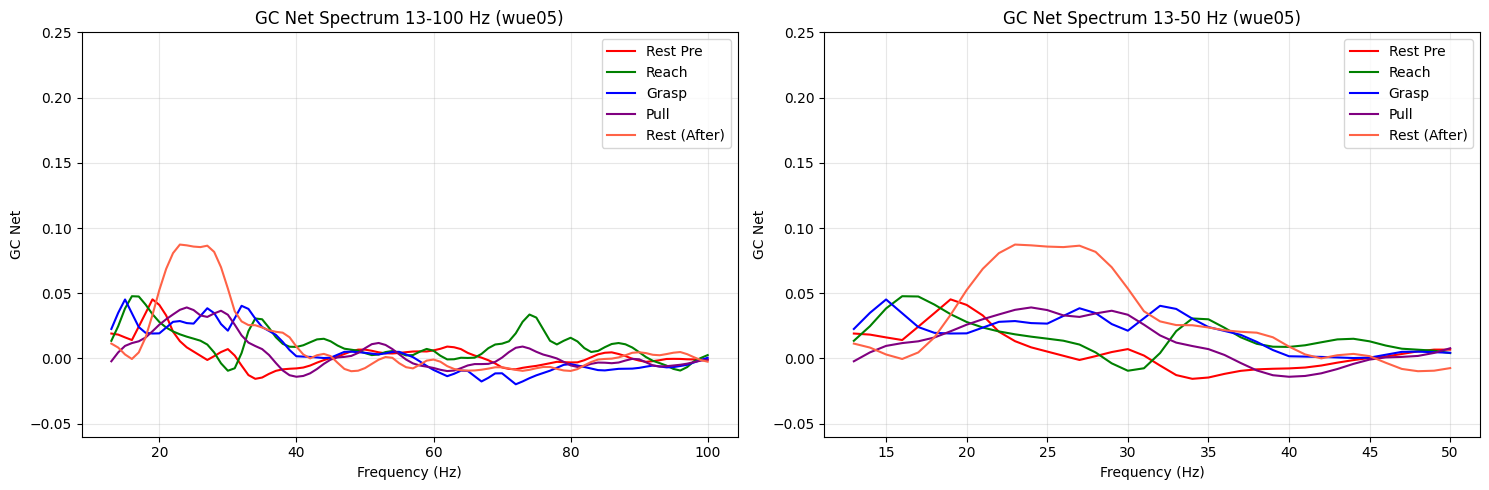


Plotting GC for subject: wue06


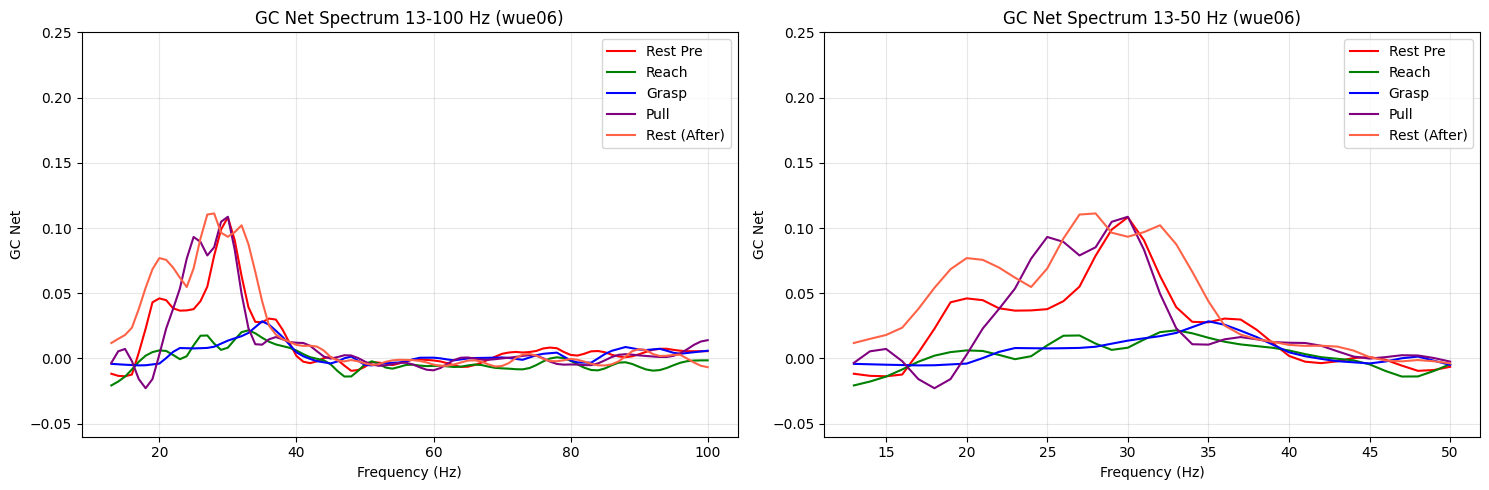


Plotting GC for subject: wue07


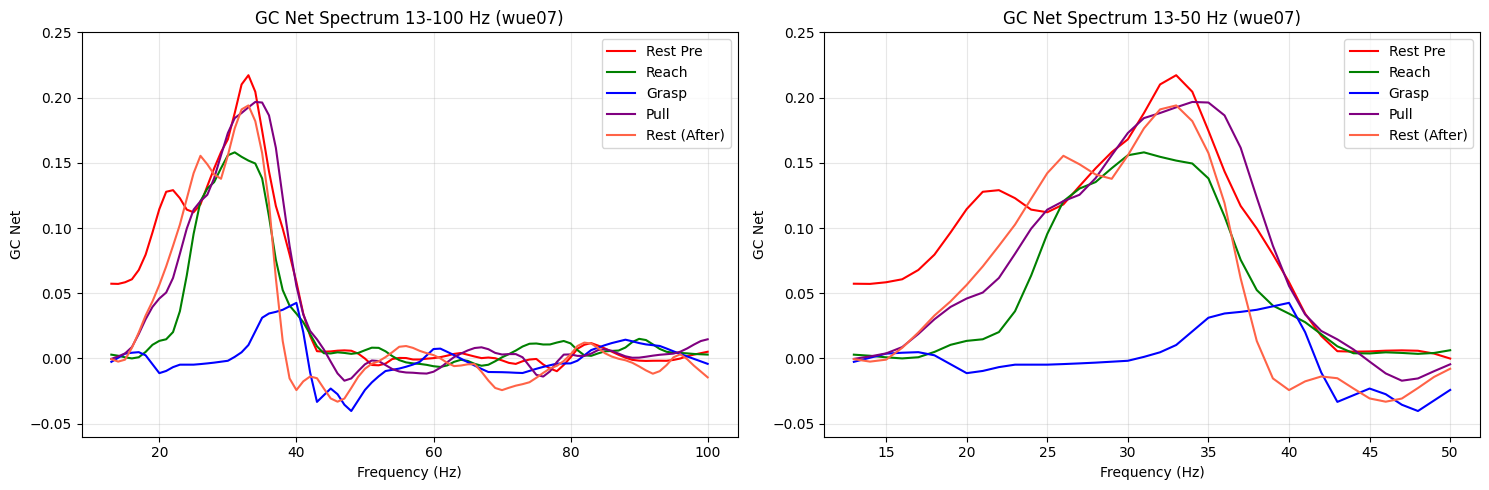


Plotting GC for subject: wue09


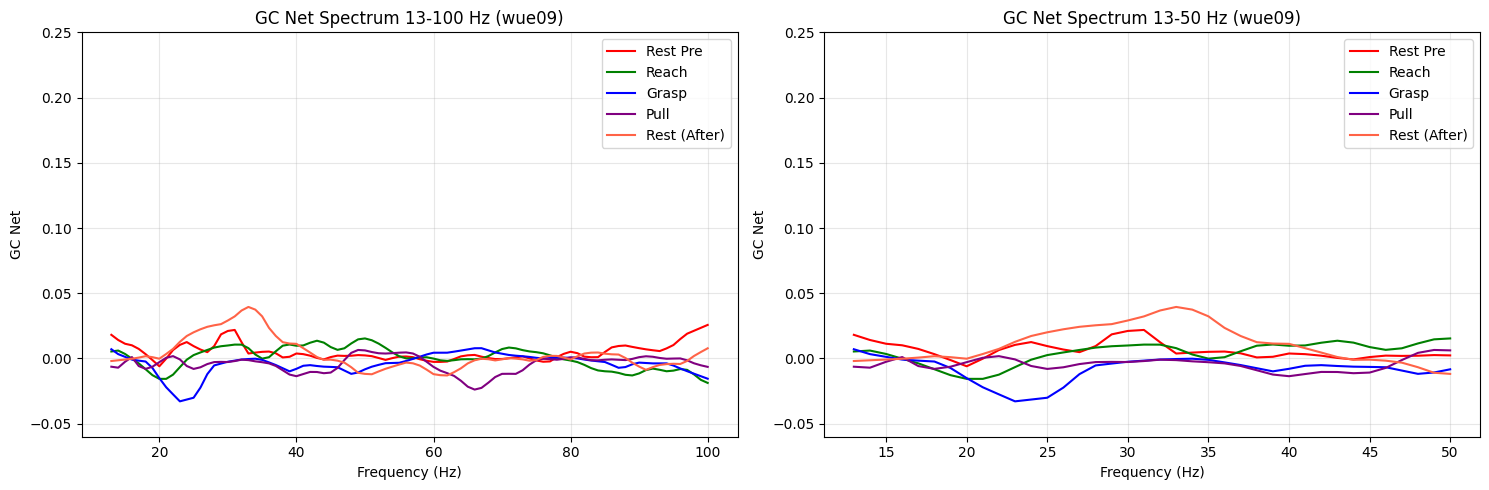


Plotting GC for subject: wue10


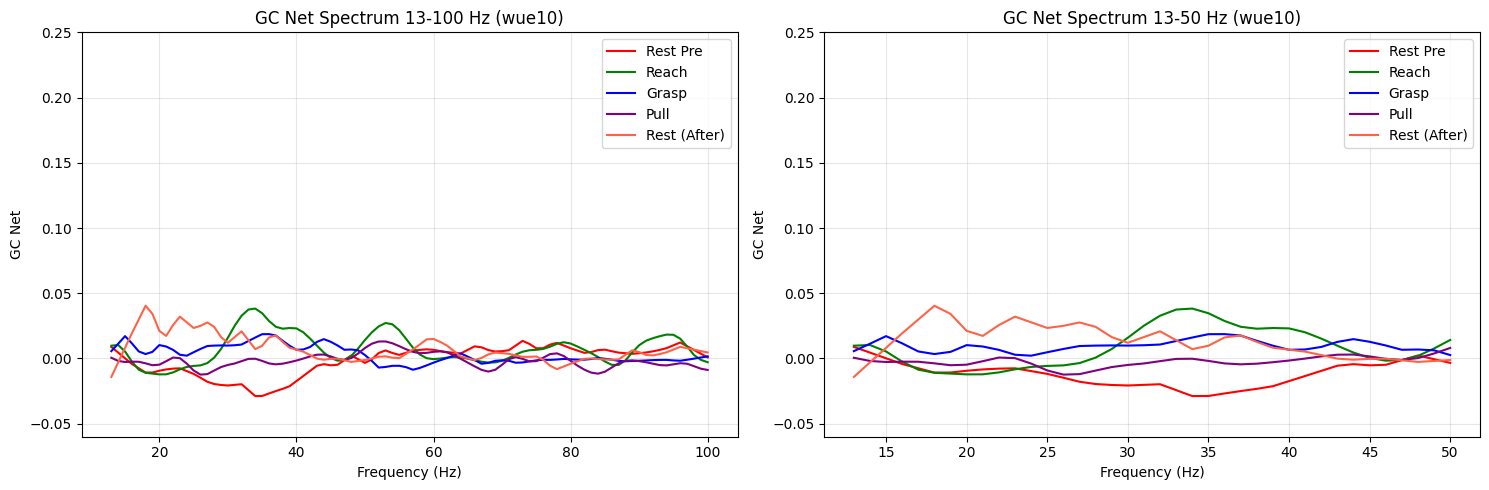


Plotting GC for subject: wue11


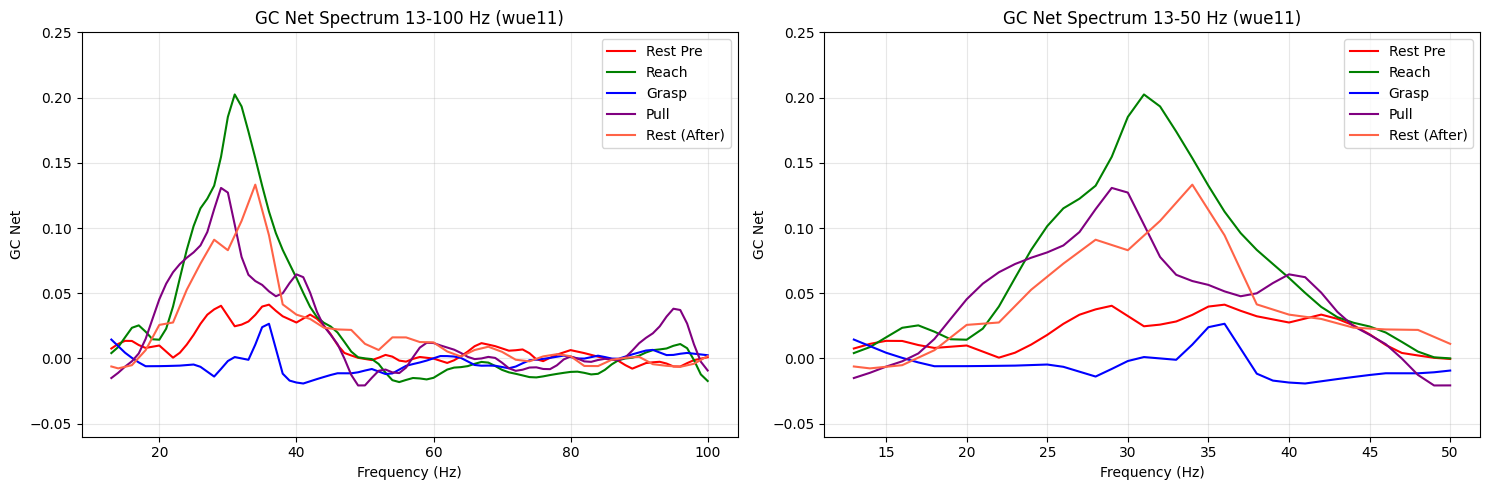

In [51]:
CLUSTER_CHANNELS = SIGNIFICANT_CLUSTER_CHANNELS

plot_phase_keys = ['phase_1', 'phase_2', 'phase_3', 'phase_4']
plot_labels = {'phase_1': 'Rest Pre', 'phase_2': 'Reach', 'phase_3': 'Grasp', 'phase_4': 'Pull'}
colors = {'phase_1': 'red', 'phase_2': 'green', 'phase_3': 'blue', 'phase_4': 'purple'}

freqs_fixed = np.arange(13, 101, 1)


# Loop su soggetti
for subject_id in subject_list:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    print(f"\nPlotting GC for subject: {subject_id}")

    cluster_idx = [
        i for i, ch in enumerate(EEG_DATA_ALL[subject_id][0]['chan_names'])
        if ch in CLUSTER_CHANNELS
    ]
    if not cluster_idx:
        continue

    # Frequenze globali
    all_freq_min = []
    all_freq_max = []
    for phase_key in plot_phase_keys + ['phase_5']:  # consideriamo anche phase_5
        freqs_phase = GC_NET_RESULTS[subject_id]['phases'][phase_key]['freqs']
        all_freq_min.append(freqs_phase[0])
        all_freq_max.append(freqs_phase[-1])
    global_fmin = np.min(all_freq_min)
    global_fmax = np.max(all_freq_max)

    # Loop su tutte le fasi che vogliamo plottare
    for phase_key in plot_phase_keys + ['phase_5']:  # phase_5 separata
        gc_vals = GC_NET_RESULTS[subject_id]['phases'][phase_key]['full']
        freqs_phase = GC_NET_RESULTS[subject_id]['phases'][phase_key]['freqs']
        gc_mean = np.mean(gc_vals[cluster_idx, :], axis=0)
        gc_cluster_mean = interpolate.interp1d(
            freqs_phase, gc_mean, kind='linear', bounds_error=False, fill_value='extrapolate'
        )(freqs_fixed)

        # Nome fase per label
        if phase_key == 'phase_5':
            label = 'Rest (After)'
            color = '#FF6347'  # rosso-arancio per distinguere
        else:
            label = plot_labels[phase_key]
            color = colors[phase_key]

        # Plot fmin-100 Hz
        axes[0].plot(freqs_fixed, gc_cluster_mean, label=label, color=color)
        # Plot fmin-40 Hz
        mask = (freqs_fixed >= global_fmin) & (freqs_fixed <= 50)
        axes[1].plot(freqs_fixed[mask], gc_cluster_mean[mask], label=label, color=color)

    # Layout
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('GC Net')
    axes[0].set_title(f'GC Net Spectrum 13-100 Hz ({subject_id})')
    axes[0].legend()
    axes[0].set_ylim(-0.06, 0.25)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('GC Net')
    axes[1].set_title(f'GC Net Spectrum 13-50 Hz ({subject_id})')
    axes[1].legend()
    axes[1].set_ylim(-0.06, 0.25)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



### GRAND AVERAGE GC NET SPECTRUM

[INFO] Range frequenze comune: 14.46 - 98.11 Hz


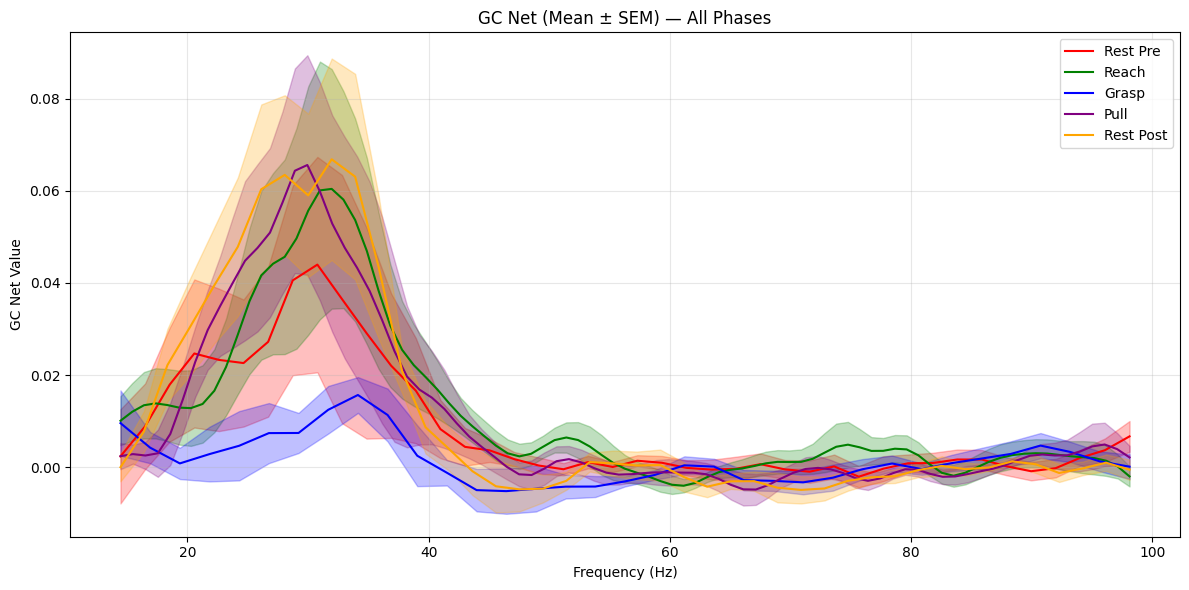

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d

# -----------------------------------------------------------
# PARAMETRI
# -----------------------------------------------------------
phase_keys = ['phase_1', 'phase_2', 'phase_3', 'phase_4', 'phase_5']

phase_labels = {
    'phase_1': 'Rest Pre',
    'phase_2': 'Reach',
    'phase_3': 'Grasp',
    'phase_4': 'Pull',
    'phase_5': 'Rest Post'
}

colors = {
    'phase_1': 'red',
    'phase_2': 'green',
    'phase_3': 'blue',
    'phase_4': 'purple',
    'phase_5': 'orange'
}

# -----------------------------------------------------------
# 1) RANGE FREQUENZE COMUNE
# -----------------------------------------------------------
all_mins, all_maxs = [], []

for subj in subject_list:
    for ph in phase_keys:
        freqs = GC_NET_RESULTS[subj]['phases'][ph]['freqs']
        all_mins.append(freqs[0])
        all_maxs.append(freqs[-1])

global_fmin = np.max(all_mins)
global_fmax = np.min(all_maxs)

print(f"[INFO] Range frequenze comune: {global_fmin:.2f} - {global_fmax:.2f} Hz")

# -----------------------------------------------------------
# FIGURA UNICA CON MEDIA + SEM
# -----------------------------------------------------------
plt.figure(figsize=(12, 6))

for ph in phase_keys:

    subject_curves = []

    # lunghezze utili per definire la griglia comune
    lengths = []
    for subj in subject_list:
        freqs = GC_NET_RESULTS[subj]['phases'][ph]['freqs']
        mask = (freqs >= global_fmin) & (freqs <= global_fmax)
        lengths.append(np.sum(mask))

    target_len = int(np.median(lengths))
    freqs_interp = np.linspace(global_fmin, global_fmax, target_len)

    # -----------------------------------------------------------
    # LOOP SOGGETTI
    # -----------------------------------------------------------
    for subj in subject_list:

        cluster_idx = [
            i for i, ch in enumerate(EEG_DATA_ALL[subj][0]['chan_names'])
            if ch in CLUSTER_CHANNELS
        ]
        if not cluster_idx:
            continue

        freqs = GC_NET_RESULTS[subj]['phases'][ph]['freqs']
        gc_vals = GC_NET_RESULTS[subj]['phases'][ph]['full']

        gc_mean = np.mean(gc_vals[cluster_idx, :], axis=0)

        mask = (freqs >= global_fmin) & (freqs <= global_fmax)
        freqs_valid = freqs[mask]
        gc_valid = gc_mean[mask]

        f_interp = interp1d(freqs_valid, gc_valid, kind='linear',
                            bounds_error=False, fill_value="extrapolate")

        gc_interp = f_interp(freqs_interp)
        subject_curves.append(gc_interp)

    if len(subject_curves) == 0:
        continue

    subject_curves = np.stack(subject_curves)

    # -----------------------------------------------------------
    # MEDIA & SEM SUI SOGGETTI
    # -----------------------------------------------------------
    mean_gc = np.mean(subject_curves, axis=0)
    sem_gc = stats.sem(subject_curves, axis=0)

    # -----------------------------------------------------------
    # PLOT MEDIA + SEM
    # -----------------------------------------------------------
    plt.plot(freqs_interp, mean_gc, label=phase_labels[ph], color=colors[ph])
    plt.fill_between(freqs_interp, mean_gc - sem_gc, mean_gc + sem_gc,
                     color=colors[ph], alpha=0.25)

plt.title("GC Net (Mean ± SEM) — All Phases")
plt.xlabel("Frequency (Hz)")
plt.ylabel("GC Net Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## BOOTSTRAP TEST GRANGER CAUSALITY

In [53]:
# File pickle bootstrap GC

full_path_bootstrap = r"C:\Users\tomma\OneDrive - University of Pisa\Desktop\TESI\Connectivity_Analysis\STATISTICAL_ANALYSIS\CONNECTIVITY\GC_BOOTSTRAP_RESULTS_final_01.pkl"

try:
    with open(full_path_bootstrap, 'rb') as f:
        GC_BOOTSTRAP_RESULTS_final = pickle.load(f)
    print(f"✅ GC_BOOTSTRAP_RESULTS_final loaded successfully from {full_path_bootstrap}")

except Exception as e:
    print(f"❌ Error loading pickle: {e}")

✅ GC_BOOTSTRAP_RESULTS_final loaded successfully from C:\Users\tomma\OneDrive - University of Pisa\Desktop\TESI\Connectivity_Analysis\STATISTICAL_ANALYSIS\CONNECTIVITY\GC_BOOTSTRAP_RESULTS_final_01.pkl


[DEBUG] Phase phase_1: 95th percentile threshold = 0.00908


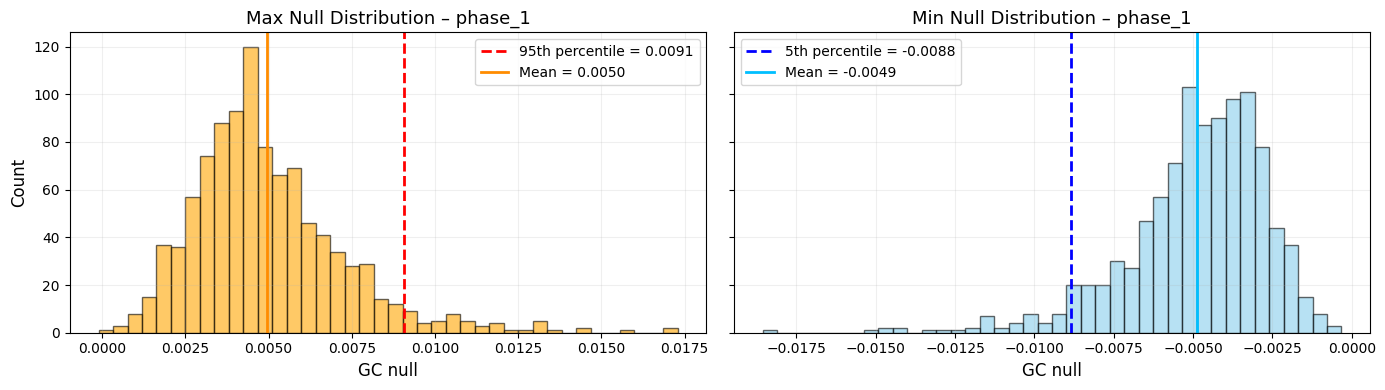

[DEBUG] Phase phase_2: 95th percentile threshold = 0.00787


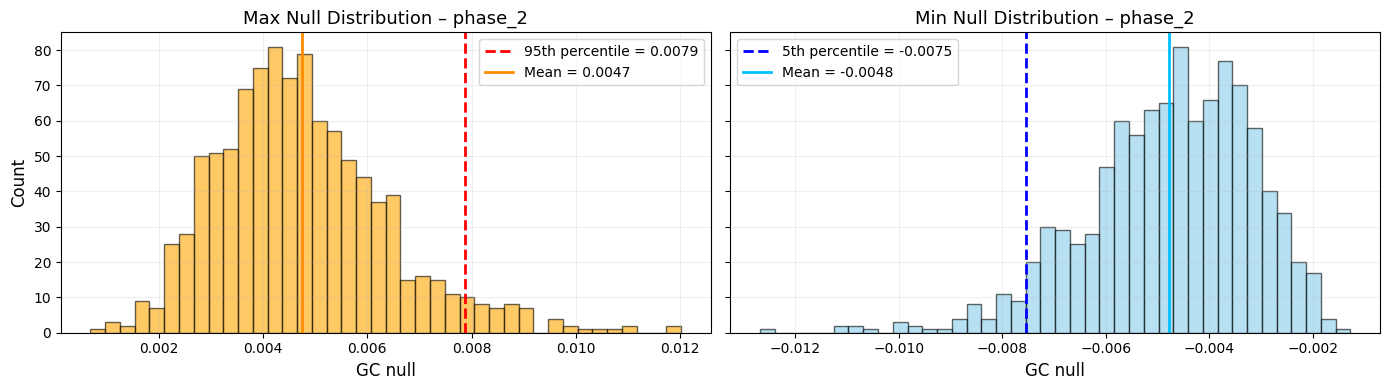

[DEBUG] Phase phase_3: 95th percentile threshold = 0.00870


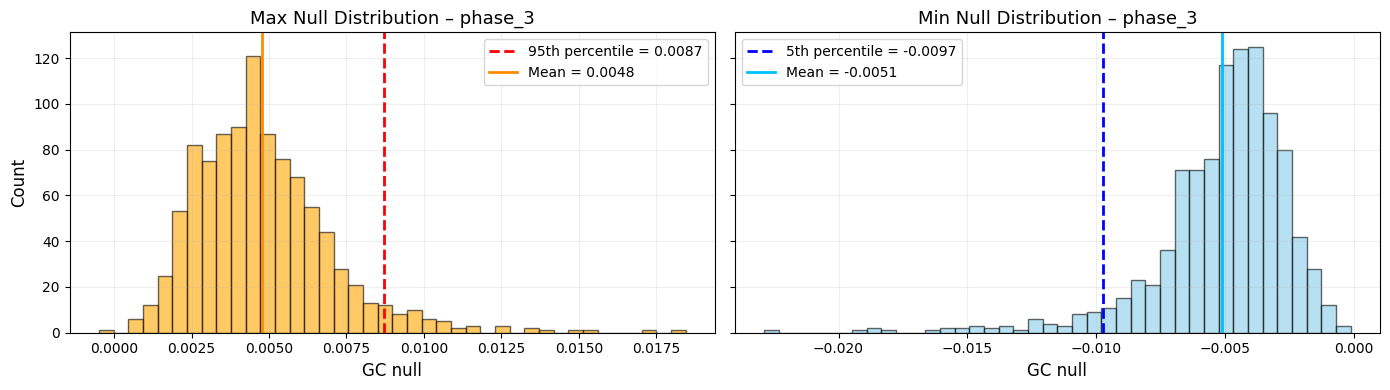

[DEBUG] Phase phase_4: 95th percentile threshold = 0.00746


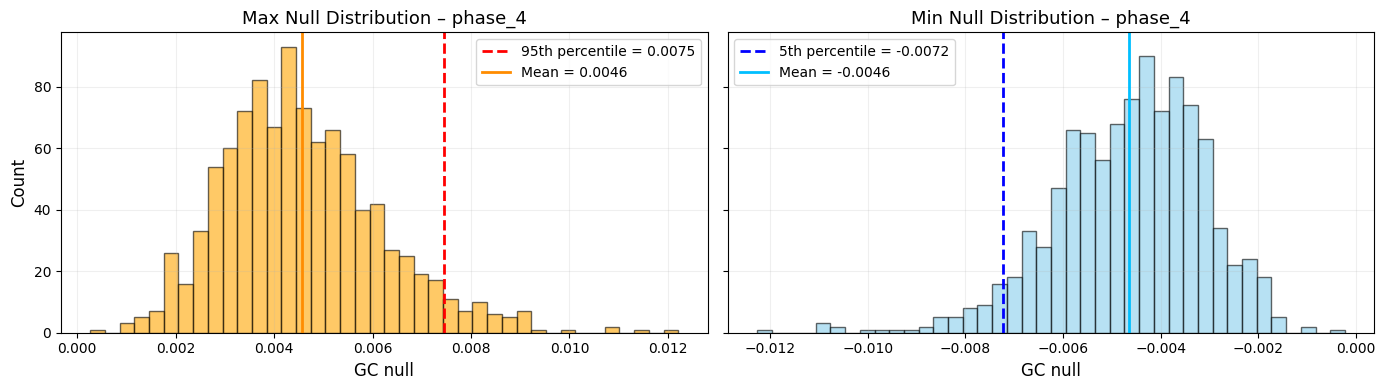

[DEBUG] Phase phase_5: 95th percentile threshold = 0.00830


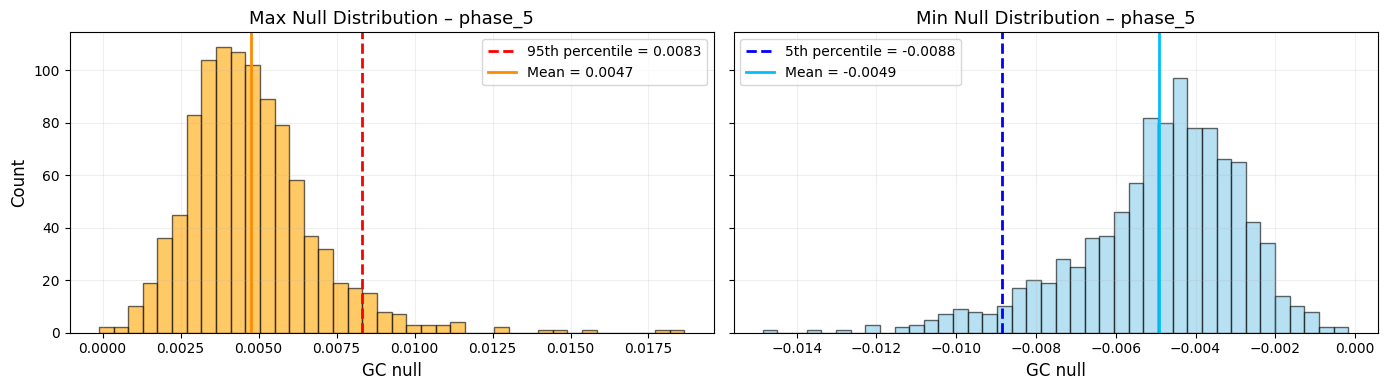


========== BANDE GC NET SIGNIFICATIVE ==========

phase_1:
   ✔ 13.0 - 15.2 Hz
   ✔ 16.9 - 40.5 Hz
-----------------------------------------------
phase_2:
   ✔ 14.3 - 44.0 Hz
-----------------------------------------------
phase_3:
   ✔ 30.5 - 37.0 Hz
-----------------------------------------------
phase_4:
   ✔ 18.7 - 42.7 Hz
-----------------------------------------------
phase_5:
   ✔ 16.5 - 39.7 Hz
-----------------------------------------------


In [ ]:
#  CALCOLO VALORE MASSIMO e MINIMO GC NET PER OGNI ITERAZIONE E FASE E SETTO THRESHOLD AL 95° PERCENTILE

import numpy as np
import statsmodels.stats.multitest as smm
from scipy.interpolate import interp1d

# -----------------------------------------------------------
# FUNZIONE CALCOLO P-VALUES FREQUENCY-WISE CON BOOTSTRAP MEDIANDO TRA SOGGETTI
# ADATTATA A GC_BOOTSTRAP_RESULTS / GC_NET_RESULTS
# -----------------------------------------------------------
def mean_level_bootstrap_test(subject_list, gc_results, bootstrap_results, cluster_idx,
                              fmin, fmax, method='fdr_bh', cluster_alpha=0.05,
                              already_avg_cluster=False):

    # fase ricavate dinamicamente
    phases = list(gc_results[subject_list[0]]['phases'].keys())
    pval_dict = {}

    common_freqs = np.linspace(fmin, fmax, 200)  # asse frequenze comune

    for phase_key in phases:

        # ===== 1) GC osservato medio tra soggetti (media canali cluster → media soggetti) =====
        gc_interp_subjects = []

        for subject_id in subject_list:
            freqs = gc_results[subject_id]['phases'][phase_key]['freqs'] 
            freqs_cut = freqs[(freqs >= fmin) & (freqs <= fmax)]
            freq_mask_obs = (freqs >= fmin) & (freqs <= fmax)
            gc_vals = np.mean(gc_results[subject_id]['phases'][phase_key]['full'][cluster_idx, :], axis=0)                      # Media tra canali del cluster e tra soggetti

            f_interp = interp1d(freqs_cut, gc_vals[freq_mask_obs], kind='linear', bounds_error=False, fill_value="extrapolate")
            gc_interp_subjects.append(f_interp(common_freqs))

        gc_obs_mean = np.mean(np.stack(gc_interp_subjects, axis=0), axis=0)


        # ===== 2) BOOTSTRAP distribuzioni nulle interpolate e mediate tra soggetti =====
        null_interp_all_subjects = []

        for subject_id in subject_list:

            if already_avg_cluster:   # se hai già fatto media cluster nel salvataggio
                null_vals = bootstrap_results[subject_id]['NET_CLUST_MEAN'][phase_key]   # (iter × freq)
                null_cluster = null_vals
            else:
                null_vals = bootstrap_results[subject_id]['NET'][phase_key]              # (iter × ch × freq)
                null_cluster = np.mean(null_vals, axis=1)                                # media canali → (iter × freq)

            freqs_subj = bootstrap_results[subject_id]['freqs'][phase_key]
            freqs_subj_cut = freqs_subj[(freqs_subj >= fmin) & (freqs_subj <= fmax)]
            freq_mask = (freqs_subj >= fmin) & (freqs_subj <= fmax)
            null_interp = np.zeros((null_cluster.shape[0], len(common_freqs)))

            for it in range(null_cluster.shape[0]):
                f_interp = interp1d(freqs_subj_cut, null_cluster[it][freq_mask], kind='linear',
                                    bounds_error=False, fill_value="extrapolate")
                null_interp[it, :] = f_interp(common_freqs)

            null_interp_all_subjects.append(null_interp)

        null_mean = np.mean(np.stack(null_interp_all_subjects, axis=0), axis=0)               # (iter × freq)   # Media tra soggetti

        max_null = np.max(null_mean, axis=1)                                            # massimo assoluto per ogni iterazione
        min_null = np.min(null_mean, axis=1)                                            # minimo assoluto per ogni iterazione   

        threshold_max = np.percentile(max_null, 95)
        threshold_min = np.percentile(min_null, 5)
        print(f"[DEBUG] Phase {phase_key}: 95th percentile threshold = {threshold_max:.5f}")

        mean_max = np.mean(max_null)
        mean_min = np.mean(min_null)

        # ===== 4) Plot istogrammi affiancati =====
        fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

        # ===== Istogramma Max Null =====
        axes[0].hist(max_null, bins=40, alpha=0.6, edgecolor='black', color='orange')
        axes[0].axvline(threshold_max, color='red', linestyle='--', linewidth=2, label=f"95th percentile = {threshold_max:.4f}")
        axes[0].axvline(mean_max, color='darkorange', linestyle='-', linewidth=2, label=f"Mean = {mean_max:.4f}")
        axes[0].set_title(f"Max Null Distribution – {phase_key}", fontsize=13)
        axes[0].set_xlabel("GC null", fontsize=12)
        axes[0].set_ylabel("Count", fontsize=12)
        axes[0].legend()
        axes[0].grid(alpha=0.2)

        # ===== Istogramma Min Null =====
        axes[1].hist(min_null, bins=40, alpha=0.6, edgecolor='black', color='skyblue')
        axes[1].axvline(threshold_min, color='blue', linestyle='--', linewidth=2, label=f"5th percentile = {threshold_min:.4f}")
        axes[1].axvline(mean_min, color='deepskyblue', linestyle='-', linewidth=2, label=f"Mean = {mean_min:.4f}")
        axes[1].set_title(f"Min Null Distribution – {phase_key}", fontsize=13)
        axes[1].set_xlabel("GC null", fontsize=12)
        axes[1].legend()
        axes[1].grid(alpha=0.2)

        plt.tight_layout()
        plt.show()

        # ===== 5) Frequenze significative =====
        significant_mask = (gc_obs_mean > threshold_max) | (gc_obs_mean < threshold_min)
        significant_freqs = common_freqs[significant_mask]

        clusters = []
        current = []
        for i, val in enumerate(significant_mask):
            if val:
                current.append(i)
            else:
                if current:
                    clusters.append(current)
                    current = []
        if current:
            clusters.append(current)

        pval_dict[phase_key] = {
            'freqs'             : common_freqs,
            'gc_obs_mean'       : gc_obs_mean,
            'threshold_max'     : threshold_max,
            'threshold_min'     : threshold_min,
            'significant_freqs' : significant_freqs,
            'clusters_idx'      : clusters,
            'clusters_hz'       : [(common_freqs[c[0]], common_freqs[c[-1]]) for c in clusters]
        }



    return pval_dict

pval_gc_freqwise_group = mean_level_bootstrap_test(
    subject_list,
    GC_NET_RESULTS,
    GC_BOOTSTRAP_RESULTS_final,
    cluster_idx,
    fmin=13, fmax=100,
    method='cbpt',     
    cluster_alpha=0.01,
    already_avg_cluster=True
)

print("\n========== BANDE GC NET SIGNIFICATIVE ==========\n")

for phase_key in pval_gc_freqwise_group.keys():
    clusters_hz = pval_gc_freqwise_group[phase_key]['clusters_hz']
    
    if len(clusters_hz) == 0:
        print(f"{phase_key}:  ❌  Nessuna banda significativa sopra soglia")
    else:
        print(f"{phase_key}:")
        for (low, high) in clusters_hz:
            print(f"   ✔ {low:.1f} - {high:.1f} Hz")
    print("-----------------------------------------------")


In [55]:
SIGNIFICANT_BANDS = {}


for phase, data in pval_gc_freqwise_group.items():
    SIGNIFICANT_BANDS[phase] = data['clusters_hz'] if data['clusters_hz'] else []


# stampa finale
for ph,bands in SIGNIFICANT_BANDS.items():
    if not bands:
        print(f"{ph} : nessuna banda significativa")
    else:
        for low,high in bands:
            print(f"{ph} : {low:.1f}-{high:.1f} Hz")

phase_1 : 13.0-15.2 Hz
phase_1 : 16.9-40.5 Hz
phase_2 : 14.3-44.0 Hz
phase_3 : 30.5-37.0 Hz
phase_4 : 18.7-42.7 Hz
phase_5 : 16.5-39.7 Hz


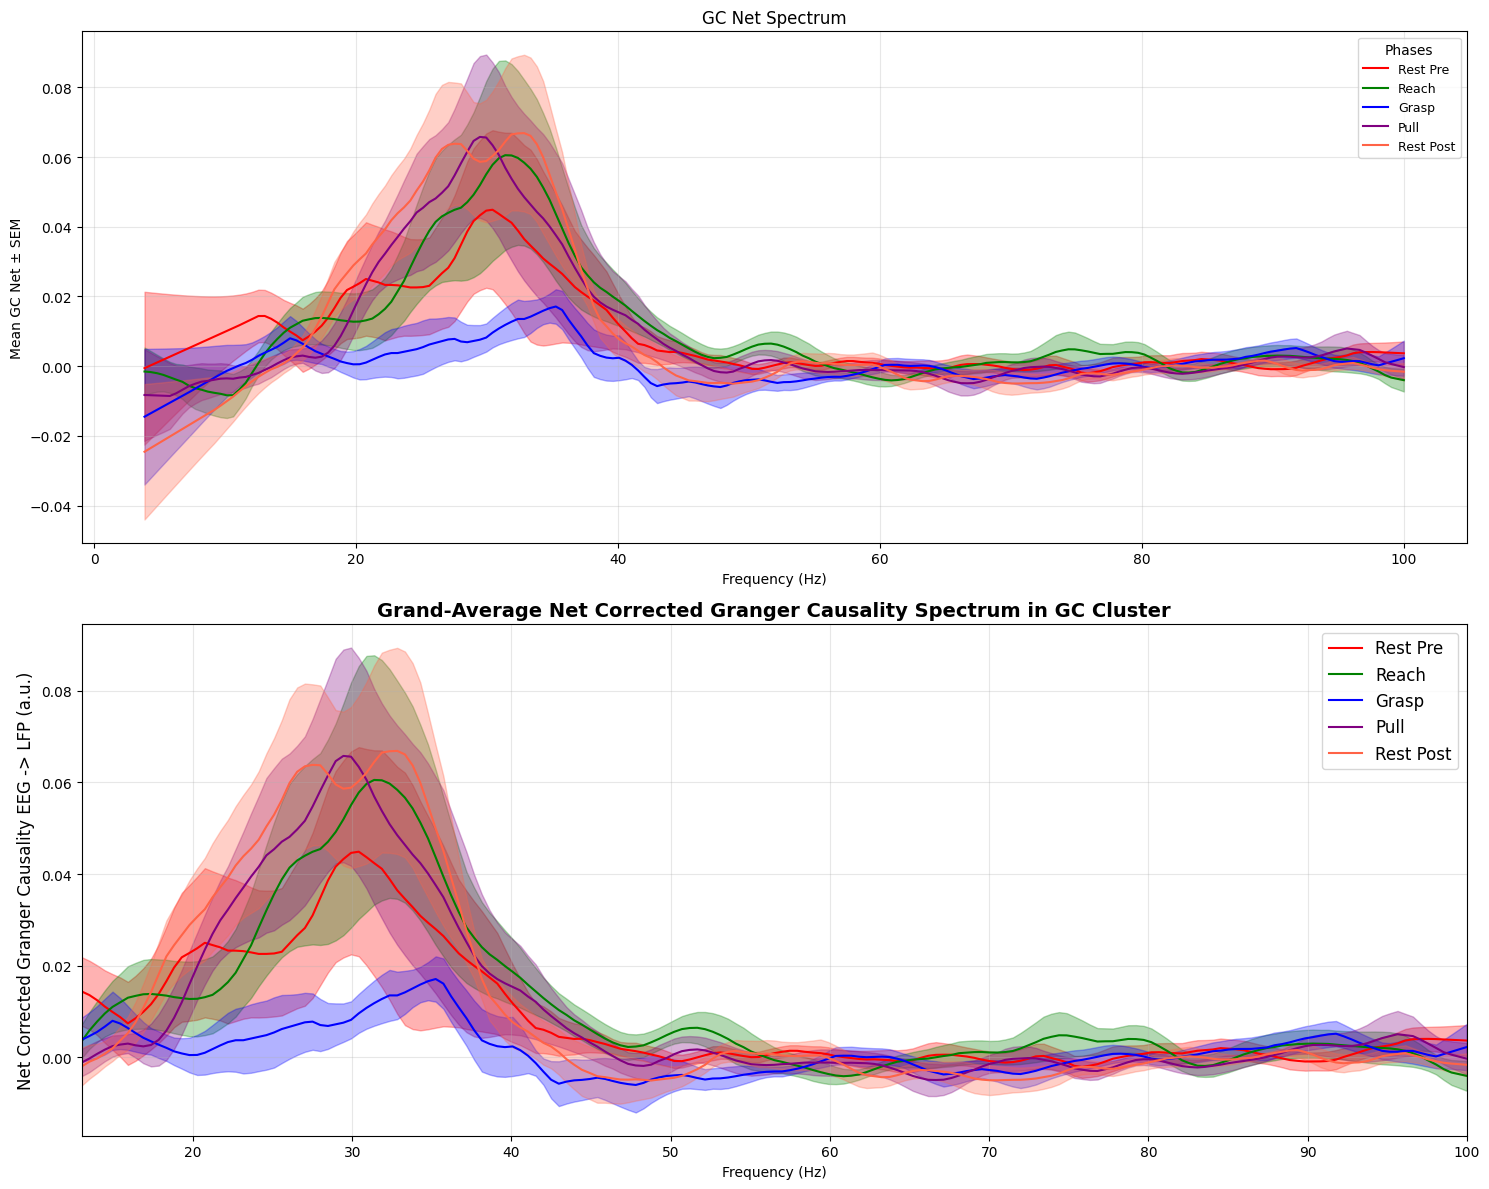

In [56]:
CLUSTER_CHANNELS = SIGNIFICANT_CLUSTER_CHANNELS

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Fasi considerate
plot_phase_keys = ['phase_1', 'phase_2', 'phase_3', 'phase_4', 'phase_5']

plot_labels = {
    'phase_1': 'Rest Pre',
    'phase_5': 'Rest Post',
    'phase_2': 'Reach',
    'phase_3': 'Grasp',
    'phase_4': 'Pull'
}
colors = {
    'phase_1': 'red',
    'phase_2': 'green',
    'phase_3': 'blue',
    'phase_4': 'purple',
    'phase_5': '#FF6347'
}

# === 1) Trova range globale delle frequenze ===
all_freq_min = []
all_freq_max = []

for subject_id in subject_list:
    for phase_key in plot_phase_keys:
        freqs_phase = GC_NET_RESULTS[subject_id]['phases'][phase_key]['freqs']
        all_freq_min.append(freqs_phase[0])
        all_freq_max.append(freqs_phase[-1])

global_fmin = np.min(all_freq_min)
global_fmax = np.max(all_freq_max)

PHASE_GC_MEAN = {}
PHASE_GC_SEM  = {}
PHASE_FREQS   = {}

# === Loop sulle fasi ===
for phase_key in plot_phase_keys:
    all_subjects_gc = []

    # --- lunghezza mediana delle frequenze reali (non shape GC!) ---
    lengths = []
    for subject_id in subject_list:
        if phase_key == 'phase_1':
            f1 = GC_NET_RESULTS[subject_id]['phases']['phase_1']['freqs']
            f5 = GC_NET_RESULTS[subject_id]['phases']['phase_5']['freqs']
            lengths.extend([len(f1), len(f5)])
        else:
            freqs_phase = GC_NET_RESULTS[subject_id]['phases'][phase_key]['freqs']
            lengths.append(len(freqs_phase))

    median_length = int(np.median(lengths))
    freqs_interp = np.linspace(global_fmin, global_fmax, 200)

    # --- Interpolazione per soggetto ---
    for subject_id in subject_list:

        cluster_idx = [
            i for i, ch in enumerate(EEG_DATA_ALL[subject_id][0]['chan_names'])
            if ch in CLUSTER_CHANNELS
        ]
        if not cluster_idx:
            continue


        freqs_phase = GC_NET_RESULTS[subject_id]['phases'][phase_key]['freqs']
        gc_vals = GC_NET_RESULTS[subject_id]['phases'][phase_key]['full']

        gc_mean = np.mean(gc_vals[cluster_idx, :], axis=0)

        gc_cluster_mean = interpolate.interp1d(
            freqs_phase, gc_mean, kind='linear', fill_value='extrapolate'
        )(freqs_interp)

        color_key = phase_key

        all_subjects_gc.append(gc_cluster_mean)

    if not all_subjects_gc:
        continue

    all_subjects_gc = np.stack(all_subjects_gc)
    mean_gc = np.mean(all_subjects_gc, axis=0)
    sem_gc = stats.sem(all_subjects_gc, axis=0)

    PHASE_GC_MEAN[phase_key] = mean_gc
    PHASE_GC_SEM[phase_key]  = sem_gc
    PHASE_FREQS[phase_key]   = freqs_interp

    # --- Plot 1-100 Hz ---
    axes[0].plot(freqs_interp, mean_gc, label=plot_labels[phase_key], color=colors[color_key])
    axes[0].fill_between(freqs_interp, mean_gc - sem_gc, mean_gc + sem_gc,
                         color=colors[color_key], alpha=0.3)

    # --- Plot 1-50 Hz ---
    mask = (freqs_interp >= 13) & (freqs_interp <= 100)
    axes[1].plot(freqs_interp[mask], mean_gc[mask], label=plot_labels[phase_key], color=colors[color_key])
    axes[1].fill_between(freqs_interp[mask], mean_gc[mask] - sem_gc[mask],
                         mean_gc[mask] + sem_gc[mask], color=colors[color_key], alpha=0.3)
                         

# === Layout ===
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Mean GC Net ± SEM')
axes[0].set_title('GC Net Spectrum')
axes[0].legend(title='Phases', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel(r'Net Corrected Granger Causality EEG -> LFP (a.u.)', fontsize=12)
axes[1].set_title('Grand-Average Net Corrected Granger Causality Spectrum in GC Cluster', fontsize=14, fontweight='bold')
axes[1].legend(title='Phases', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=12)
axes[1].set_xlim(13, 100)

plt.tight_layout()
plt.show()


C:\Users\tomma\AppData\Local\Temp\ipykernel_6392\257299643.py:97: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


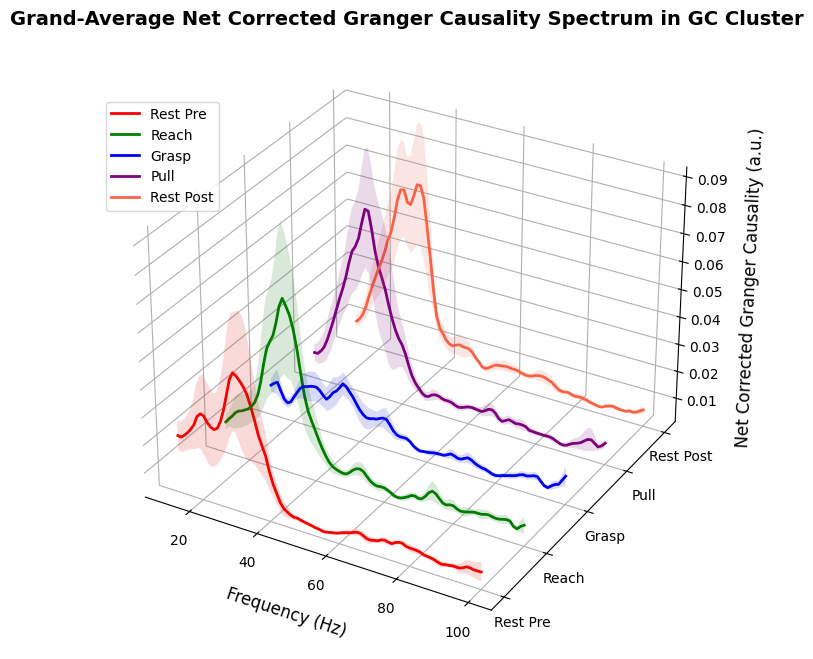

In [57]:
from mpl_toolkits.mplot3d import Axes3D  

# --- Parametri ---
plot_phase_keys = ['phase_1', 'phase_5', 'phase_2', 'phase_3', 'phase_4']
ordered_phases = ['phase_1', 'phase_2', 'phase_3', 'phase_4', 'phase_5']
phase_positions = {
    'phase_1': 0, 'phase_2': 1, 'phase_3': 2, 'phase_4': 3, 'phase_5': 4
}
plot_labels = {
    'phase_1': 'Rest Pre', 'phase_5': 'Rest Post',
    'phase_2': 'Reach', 'phase_3': 'Grasp', 'phase_4': 'Pull'
}

# --- Dizionari per salvare dati interpolati ---
mean_dict = {}
sem_dict = {}
freqs_dict = {}

freqs_fixed = np.arange(8, 101, 1)  # griglia regolare

for phase_key in plot_phase_keys:
    all_subjects_gc = []

    for subject_id in subject_list:
        all_ch = EEG_DATA_ALL[subject_id][0]['chan_names']
        cluster_idx = [i for i, ch in enumerate(all_ch) if ch in CLUSTER_CHANNELS]
        if not cluster_idx:
            continue


        gc_vals = GC_NET_RESULTS[subject_id]['phases'][phase_key]['full']
        f_phase = GC_NET_RESULTS[subject_id]['phases'][phase_key]['freqs']

        icoh_cluster_mean = interpolate.interp1d(
            f_phase, np.mean(np.abs(gc_vals[cluster_idx, :]), axis=0),
            kind='linear', bounds_error=False, fill_value="extrapolate"
        )(freqs_fixed)

        all_subjects_gc.append(icoh_cluster_mean)

    if all_subjects_gc:
        all_subjects_gc = np.stack(all_subjects_gc)
        mean_dict[phase_key] = np.mean(all_subjects_gc, axis=0)
        sem_dict[phase_key] = stats.sem(all_subjects_gc, axis=0)
        freqs_dict[phase_key] = freqs_fixed
    else:
        print(f"⚠️ Nessun dato per {phase_key}, fase saltata")

# --- Definisci maschera frequenze >= 13 Hz ---
freq_mask = freqs_fixed >= 13

# --- Plot 3D ---
fig_3d = plt.figure(figsize=(14, 8))
ax3d = fig_3d.add_subplot(111, projection='3d')

for phase_key in ordered_phases:
    if phase_key not in mean_dict:
        continue
    freqs_interp = freqs_dict[phase_key][freq_mask]  # applica maschera
    mean_gc = mean_dict[phase_key][freq_mask]
    sem_gc = sem_dict[phase_key][freq_mask]
    Y = np.ones_like(freqs_interp) * phase_positions[phase_key]

    # Curva principale
    ax3d.plot(freqs_interp, Y, mean_gc,
              color=colors[phase_key],
              label=plot_labels[phase_key],
              linewidth=2)

    # SEM come superficie sottile
    ax3d.plot_surface(
        np.vstack([freqs_interp, freqs_interp]),
        np.vstack([Y, Y]),
        np.vstack([mean_gc - sem_gc, mean_gc + sem_gc]),
        color=colors[phase_key],
        alpha=0.15,
        linewidth=0
    )

# Etichette e estetica
ax3d.set_xlabel("Frequency (Hz)", fontsize=12, labelpad=10)
ax3d.set_zlabel("Net Corrected Granger Causality (a.u.)", fontsize=12, labelpad=10)
ax3d.set_yticks(list(phase_positions.values()))
ax3d.set_yticklabels([plot_labels[k] for k in ordered_phases])
ax3d.set_title("Grand-Average Net Corrected Granger Causality Spectrum in GC Cluster", fontsize=14, fontweight='bold')

# Estetica background
fig_3d.patch.set_facecolor('white')
ax3d.set_facecolor('white')
for axis in [ax3d.xaxis, ax3d.yaxis, ax3d.zaxis]:
    axis.pane.set_facecolor((1, 1, 1, 0))
    axis.pane.set_edgecolor('white')

ax3d.grid(True, alpha=0.15)
ax3d.legend(loc='center left', bbox_to_anchor=(0, 0.8), title=None)
plt.subplots_adjust(left=0.3)
plt.tight_layout()
plt.show()


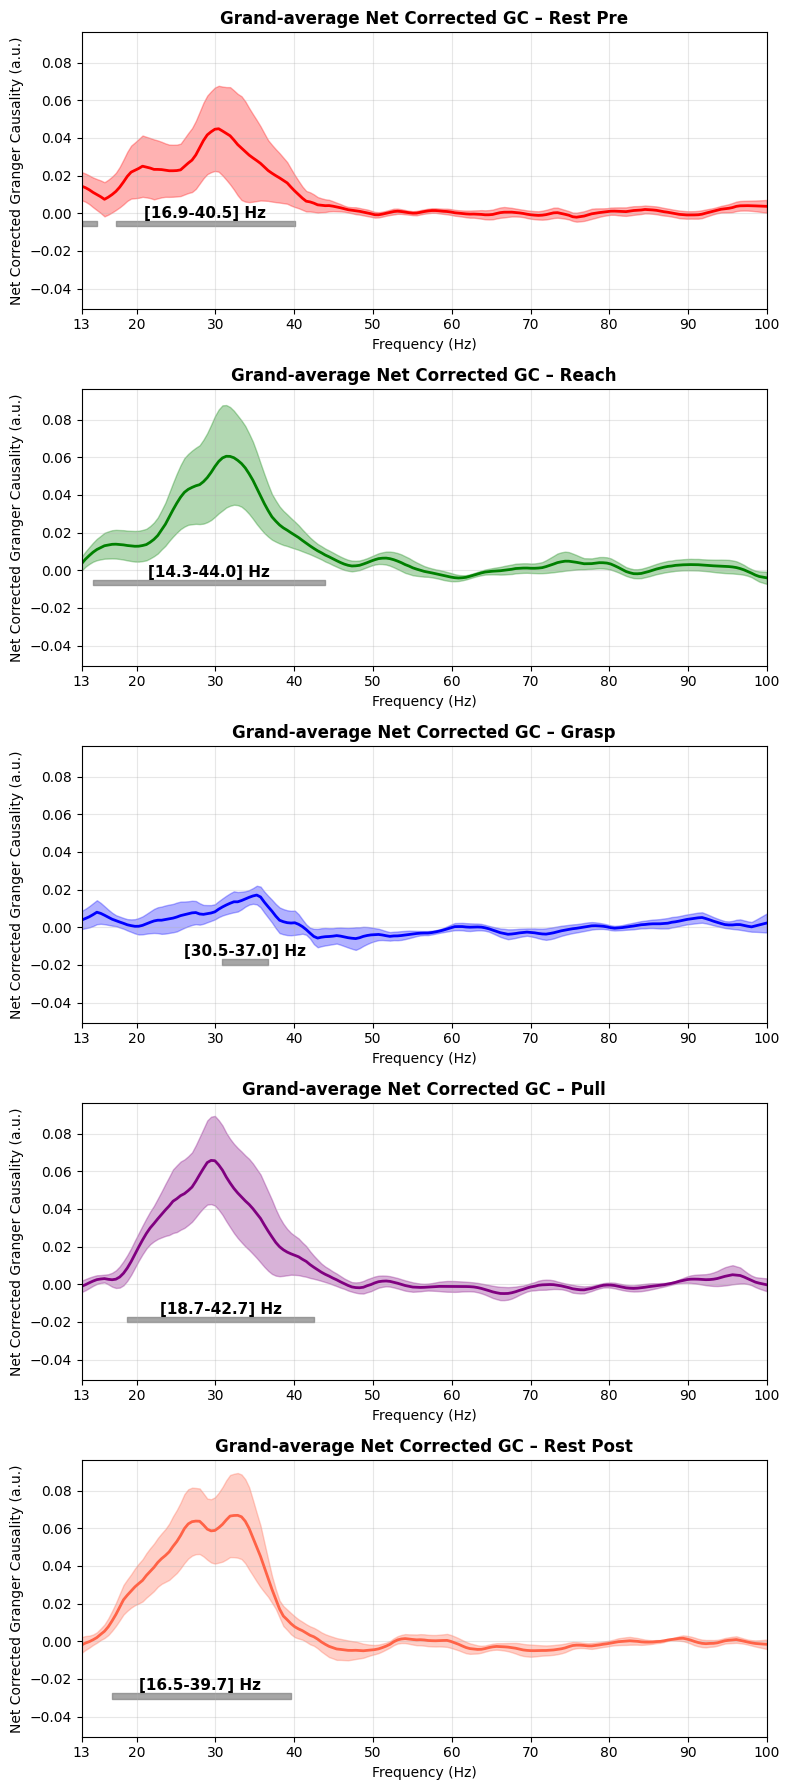

In [58]:
fig2, axs = plt.subplots(5, 1, figsize=(8, 18), sharey=True, sharex=True)


single_phases = ['phase_1', 'phase_2', 'phase_3', 'phase_4', 'phase_5']
phase_labels  = ['Rest Pre', 'Reach', 'Grasp', 'Pull', 'Rest Post']

for i, ph in enumerate(single_phases):
    ax = axs[i]

    freqs = PHASE_FREQS[ph]
    mean  = PHASE_GC_MEAN[ph]
    sem   = PHASE_GC_SEM[ph]

    ax.plot(freqs, mean, color=colors[ph], lw=2)
    ax.fill_between(freqs, mean-sem, mean+sem,
                    color=colors[ph], alpha=0.3)

    ax.set_title(f"Grand-average Net Corrected GC – {phase_labels[i]}", fontsize=12, fontweight='bold')
    ax.set_xlim(13, 100)
    ax.grid(True, alpha=0.3)

    ymin, ymax = ax.get_ylim()

    # Find largest significantband 
    largest_band = None
    for low, high in SIGNIFICANT_BANDS.get(ph, []):
        if largest_band is None or (high - low) > (largest_band[1] - largest_band[0]):
            largest_band = (low, high)

    for low, high in SIGNIFICANT_BANDS.get(ph, []):
        mask = (freqs >= low) & (freqs <= high)
        y0 = ymin + 0.02 
        y1 = ymin + 0.023

        ax.fill_between(freqs[mask], y0, y1,
                        color="gray", alpha=0.7)
        if largest_band == (low, high):
            ax.text((low+high)/2, y1, f"[{low:.1f}-{high:.1f}] Hz",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

    xticks = [13, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    ax.set_xlabel("Frequency (Hz)")
    ax.set_xticks
    ax.set_ylabel("Net Corrected Granger Causality (a.u.)")
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(f) for f in xticks], fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)

plt.tight_layout()
plt.show()


## T-TEST DIFFERENCES REST PRE VS REST POST

In [63]:
import numpy as np
from scipy import stats

high_beta_band = (20, 30)

gc_beta_rest_pre  = []
gc_beta_rest_post = []

for subject_id in subject_list:

    cluster_idx = [
        i for i, ch in enumerate(EEG_DATA_ALL[subject_id][0]['chan_names'])
        if ch in CLUSTER_CHANNELS
    ]
    if not cluster_idx:
        continue

    # -------- Rest Pre (phase_1) --------
    gc_vals_pre = GC_NET_RESULTS[subject_id]['phases']['phase_1']['full']
    freqs_pre   = GC_NET_RESULTS[subject_id]['phases']['phase_1']['freqs']

    gc_mean_pre = np.mean(gc_vals_pre[cluster_idx, :], axis=0)

    beta_mask_pre = (freqs_pre >= high_beta_band[0]) & (freqs_pre <= high_beta_band[1])
    gc_beta_rest_pre.append(np.mean(gc_mean_pre[beta_mask_pre]))

    # -------- Rest Post (phase_5) --------
    gc_vals_post = GC_NET_RESULTS[subject_id]['phases']['phase_5']['full']
    freqs_post   = GC_NET_RESULTS[subject_id]['phases']['phase_5']['freqs']

    beta_mask_post = (freqs_post >= high_beta_band[0]) & (freqs_post <= high_beta_band[1])

    gc_mean_post = np.mean(gc_vals_post[cluster_idx, :], axis=0)

    gc_beta_rest_post.append(np.mean(gc_mean_post[beta_mask_post]))

t_stat, p_val = stats.ttest_rel(gc_beta_rest_post, gc_beta_rest_pre)
test_name = "Paired t-test"
#t_stat, p_val = stats.wilcoxon(gc_beta_rest_post, gc_beta_rest_pre)
#test_name = "Wilcoxon signed-rank"

print("=== Beta band GC (20–30 Hz) ===")
print(f"Test: {test_name}")
print(f"N subjects: {len(gc_beta_rest_pre)}")
print(f"Rest Pre  : {np.mean(gc_beta_rest_pre):.4f} ± {np.std(gc_beta_rest_pre)/np.sqrt(len(gc_beta_rest_pre)):.4f}")
print(f"Rest Post : {np.mean(gc_beta_rest_post):.4f} ± {np.std(gc_beta_rest_post)/np.sqrt(len(gc_beta_rest_post)):.4f}")
print(f"Statistic: {t_stat:.3f}")
print(f"p-value  : {p_val:.3f}")

=== Beta band GC (20–30 Hz) ===
Test: Paired t-test
N subjects: 8
Rest Pre  : 0.0275 ± 0.0148
Rest Post : 0.0493 ± 0.0137
Statistic: 2.453
p-value  : 0.044


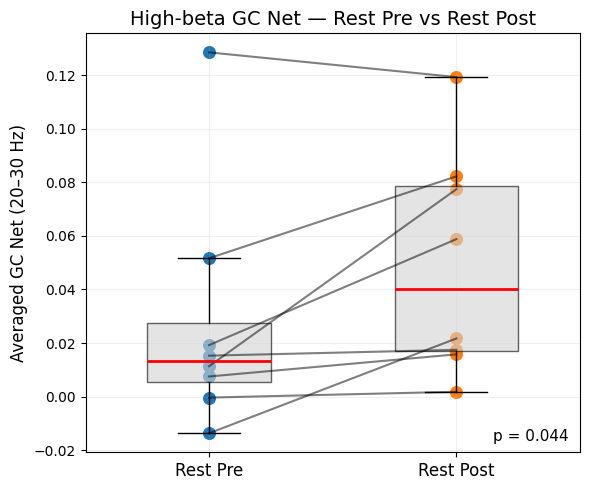

In [64]:

vals_A = np.array(gc_beta_rest_pre)
vals_B = np.array(gc_beta_rest_post)

plt.figure(figsize=(6, 5))
positions = [1, 2]

# boxplot
plt.boxplot([vals_A, vals_B],
            positions=positions,
            widths=0.5,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor='lightgray', alpha=0.6),
            medianprops=dict(color='red', linewidth=2))

# scatter soggetti
plt.scatter(np.full(len(vals_A), positions[0]), vals_A, s=70)
plt.scatter(np.full(len(vals_B), positions[1]), vals_B, s=70)

# collegamenti paired
for a, b in zip(vals_A, vals_B):
    plt.plot([positions[0], positions[1]], [a, b],
             color='black', alpha=0.5)

plt.xticks(positions, ['Rest Pre', 'Rest Post'], fontsize=12)
plt.ylabel("Averaged GC Net (20–30 Hz)", fontsize=12)
plt.title("High-beta GC Net — Rest Pre vs Rest Post", fontsize=14)
plt.grid(alpha=0.2)

# p-value in basso a destra (come nel tuo template)
y_min, y_max = plt.ylim()
plt.text(2.15, y_min + 0.02 * (y_max - y_min),
         f"p = {p_val:.3f}",
         ha='left', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()
